## **Connect Colab**

In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"] = "xx"

In [3]:
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 9 file(s) under /src/
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/pretrained.py

 All files saved under /content/src/
Contents of /content/src/:
/content/src/config/config.py
/content/src/config/__pycache__/config.cpython-312.pyc
/content/src/data/dataset.py
/content/src/data/preprocessing.py
/content/src/data/study_dataset.py
/content/src/fine_tune/trainer.py
/content/src/fine_tune/visualizer.py
/c

## **Download DATASET**

In [4]:
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [5]:
# imports
%run /content/src/imports.py
criterion = nn.CrossEntropyLoss()

Using device: cuda


## **Study Dataset**

  Loaded train: 10,055 rows
  Loaded val  : 1,673 rows
  Loaded test : 1,723 rows
  Total videos  : 13,451
  Total classes : 101

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13451 entries, 0 to 13450
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   clip_name  13451 non-null  object
 1   clip_path  13451 non-null  object
 2   label      13451 non-null  object
dtypes: object(3)
memory usage: 315.4+ KB


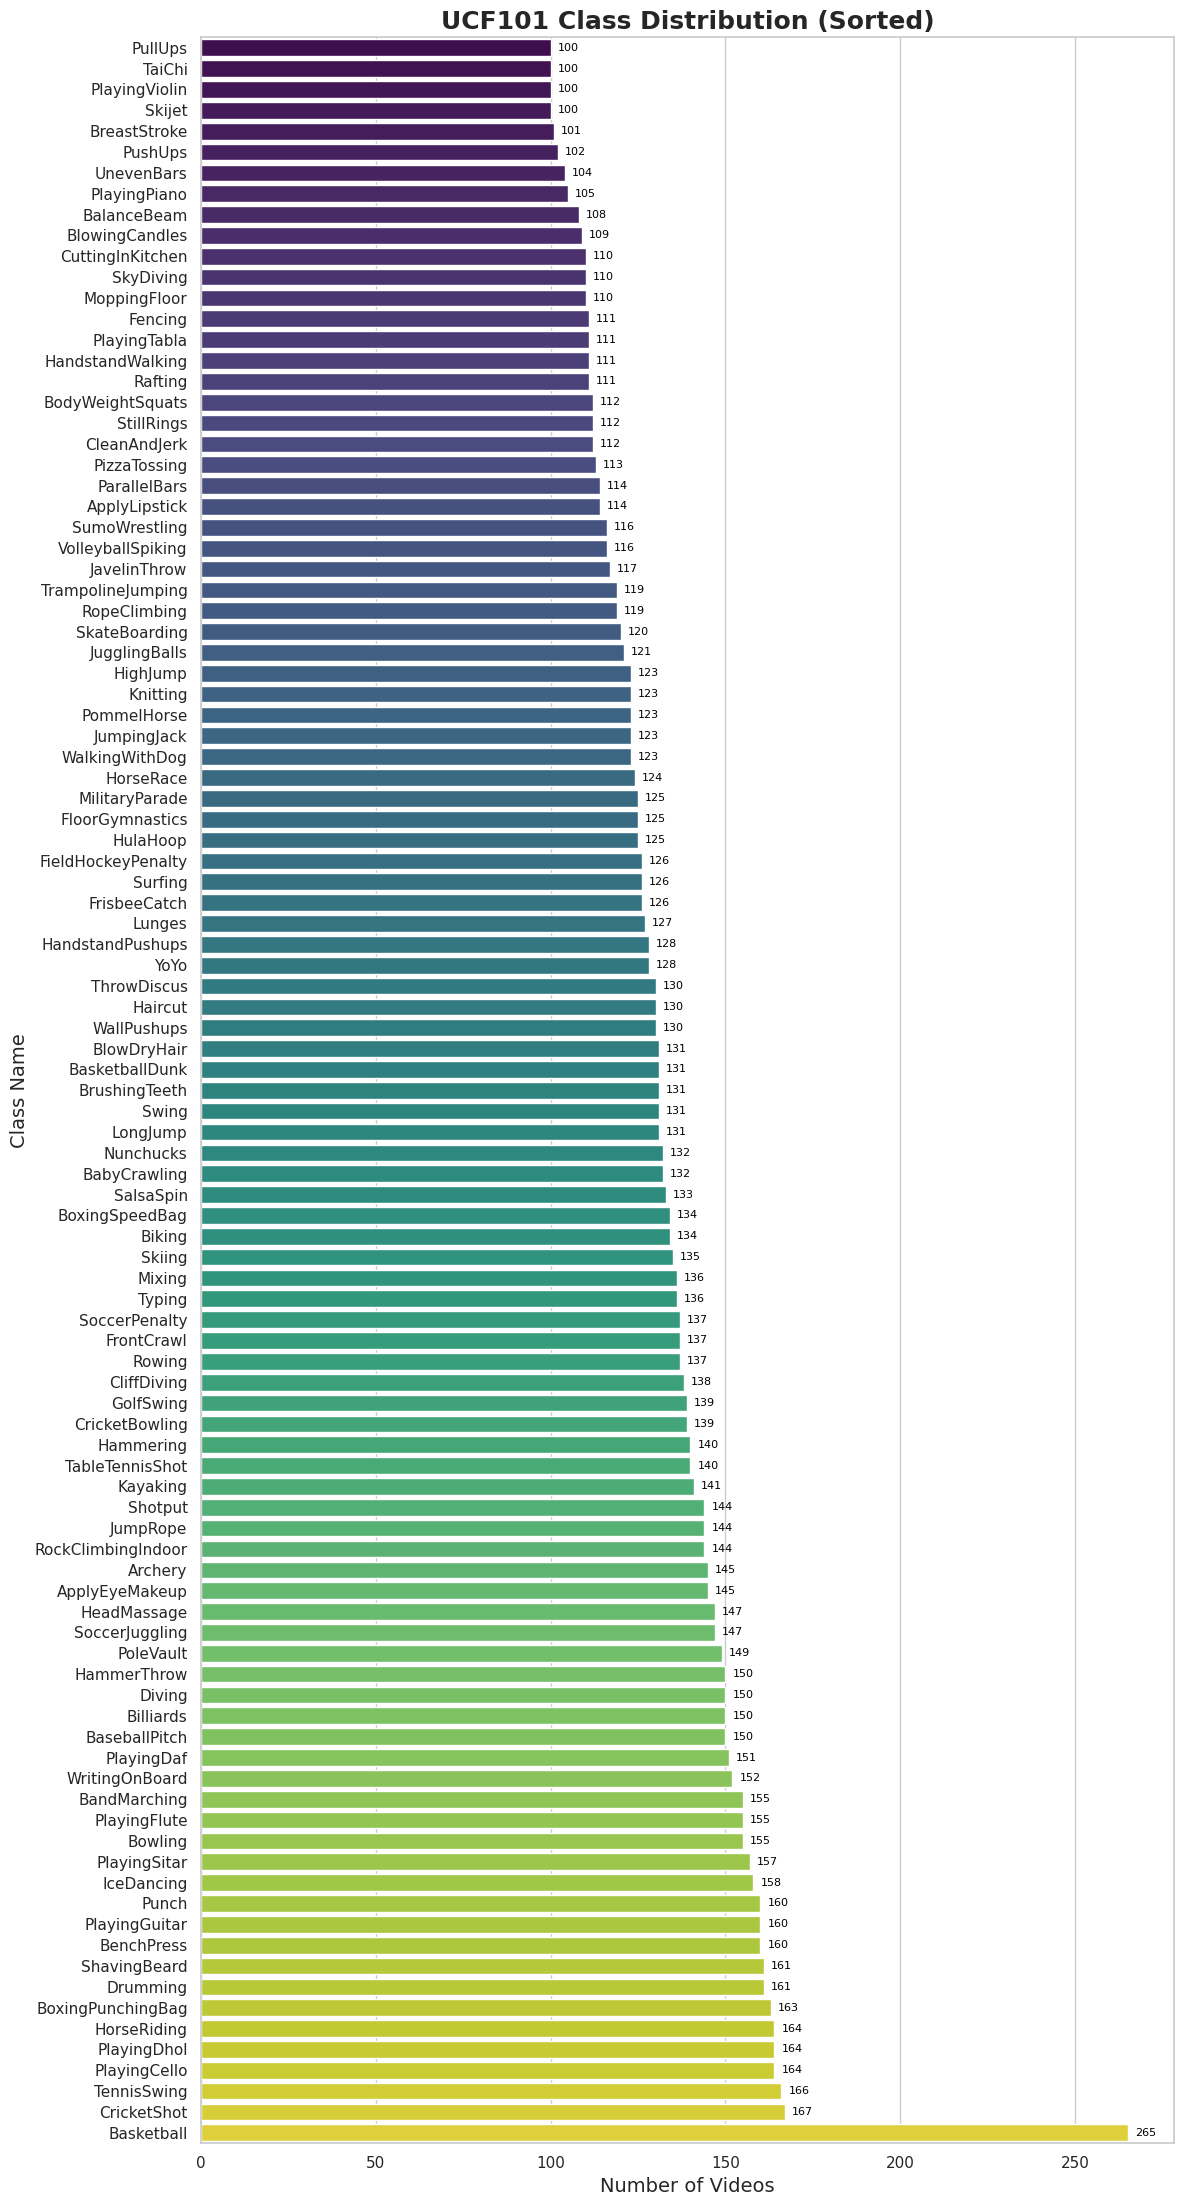

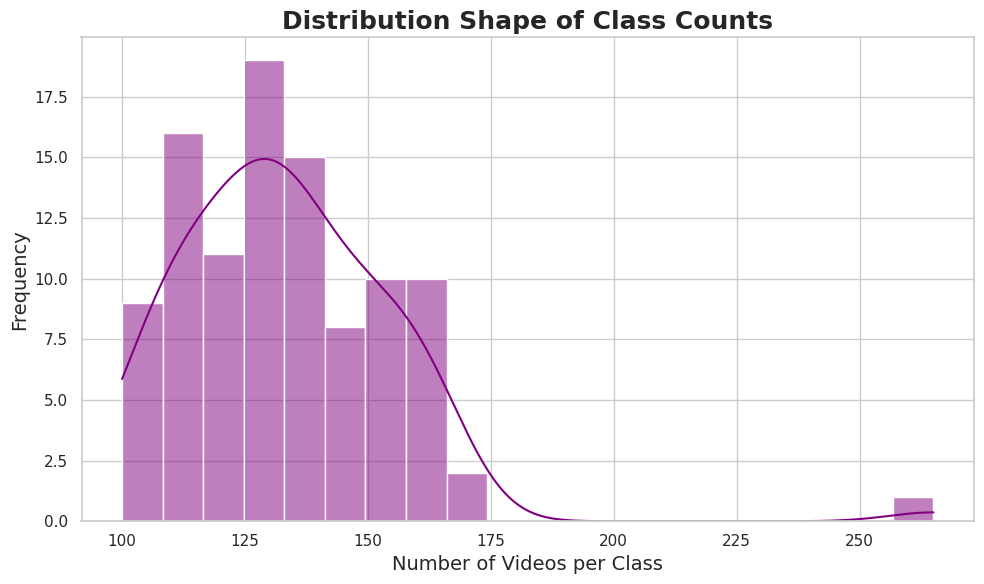

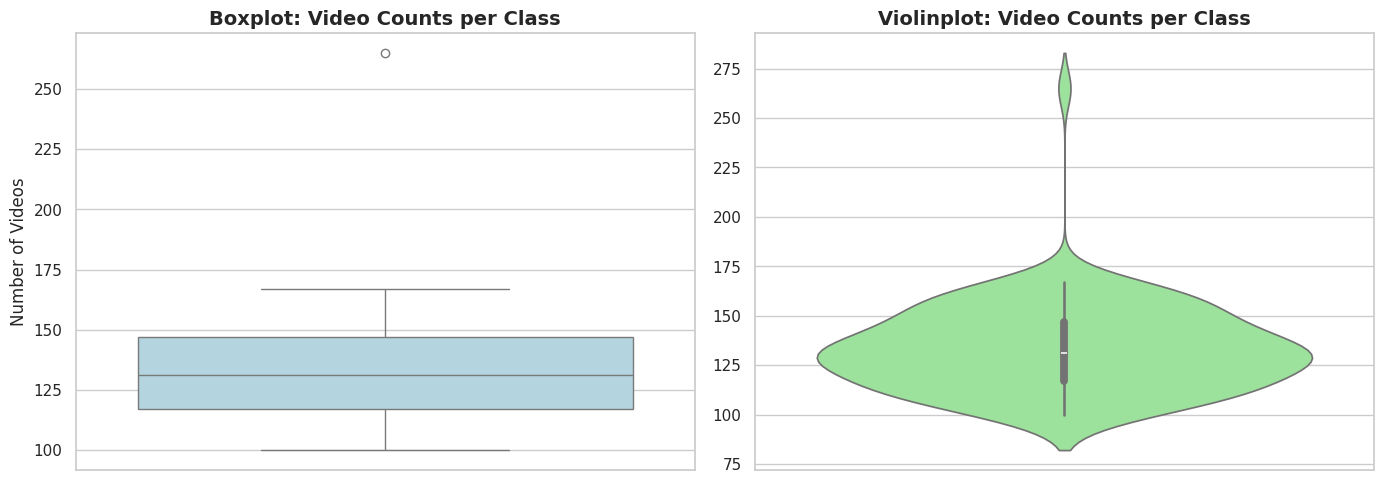


Outlier Classes Detected (IQR Method):
     Class  Count
Basketball    265


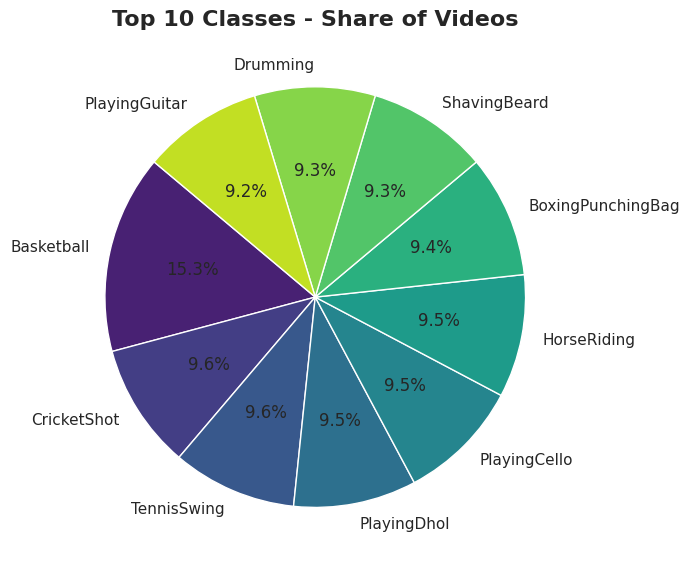


Class Balance Score (std/mean): 0.170
  Dataset is moderately balanced.


In [6]:
study = DatasetStudy()
study.run_all()

## **Preprocess the data**

In [7]:
# specifying the split (ex: "[val]")
preprocess_dataset()

Preprocessing UCF101
  from   : /kaggle/input/ucf101-action-recognition/
  to     : /kaggle/working/ucf101-processed/
  splits : ['train', 'val', 'test']

-> Split: train


  Diving [train]: 100%|██████████| 112/112 [00:14<00:00,  7.61it/s]


-> Split: val


  Diving [val]: 100%|██████████| 19/19 [00:01<00:00,  9.57it/s]


-> Split: test


  Diving [test]: 100%|██████████| 19/19 [00:02<00:00,  9.35it/s]


Done! Processed data saved at: /kaggle/working/ucf101-processed/


## **DataLoaders**

torch.Size([4, 16, 3, 224, 224])
torch.Size([4])


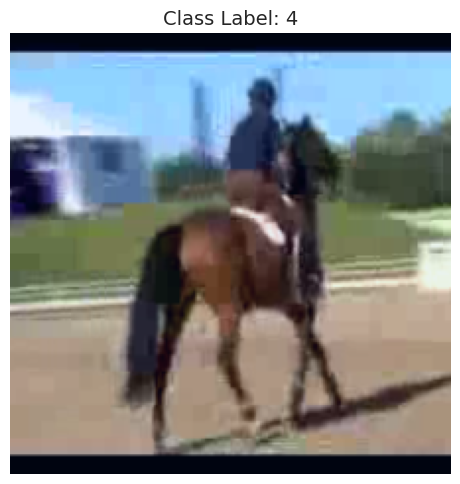

In [8]:
# datasets and loaders
CLASSES_LIST = SELECTED_CLASSES
num_classes  = len(CLASSES_LIST)

train_dataset = UCF101Clips(OUTPUT_ROOT, split="train")
val_dataset   = UCF101Clips(OUTPUT_ROOT, split="val")
test_dataset  = UCF101Clips(OUTPUT_ROOT, split="test")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# check and visualize
for clips, labels in train_loader:
    print(clips.shape)   # [B, T, C, H, W]
    print(labels.shape)  # [B]
    UCF101Clips.show_frame(clips, labels)
    break

In [9]:
print(len(SELECTED_CLASSES))

10


## **RESNET18 + LSTM**

In [10]:
# model
model = ResNet18LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


In [11]:
summary(model, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet18LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 512, 1, 1]           --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 64, 56, 56]          --
│    │    └─BasicBlock: 3-1                   [16, 64, 56, 56]          (73,984)
│    │    └─BasicBlock: 3-2                   [16, 64, 56, 56]          (73,984)
│    └─Sequential: 2-6                        [16, 128, 28, 28]         --
│    │    └─BasicBlock: 3-3                   [16, 128, 28, 28]         (230,144)
│    │    └─BasicBlock: 3-4                   [16, 128, 28, 28]     

In [12]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [13]:
results = fine_tune_model(model, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=False)

Epoch [1/10] Train Loss: 1.1312 Acc: 0.6972 | Val Loss: 0.2678 Acc: 0.9394
Epoch [2/10] Train Loss: 0.3837 Acc: 0.9064 | Val Loss: 0.1680 Acc: 0.9576
Epoch [3/10] Train Loss: 0.2232 Acc: 0.9537 | Val Loss: 0.1413 Acc: 0.9515
Epoch [4/10] Train Loss: 0.1554 Acc: 0.9618 | Val Loss: 0.0912 Acc: 0.9697
Epoch [5/10] Train Loss: 0.1236 Acc: 0.9678 | Val Loss: 0.1669 Acc: 0.9394
Epoch [6/10] Train Loss: 0.1014 Acc: 0.9799 | Val Loss: 0.0927 Acc: 0.9636
Epoch [7/10] Train Loss: 0.1470 Acc: 0.9618 | Val Loss: 0.1027 Acc: 0.9697
Epoch [8/10] Train Loss: 0.1072 Acc: 0.9728 | Val Loss: 0.1183 Acc: 0.9697
Epoch [9/10] Train Loss: 0.0815 Acc: 0.9789 | Val Loss: 0.1301 Acc: 0.9636
Epoch [10/10] Train Loss: 0.0858 Acc: 0.9759 | Val Loss: 0.0980 Acc: 0.9697


In [14]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9649


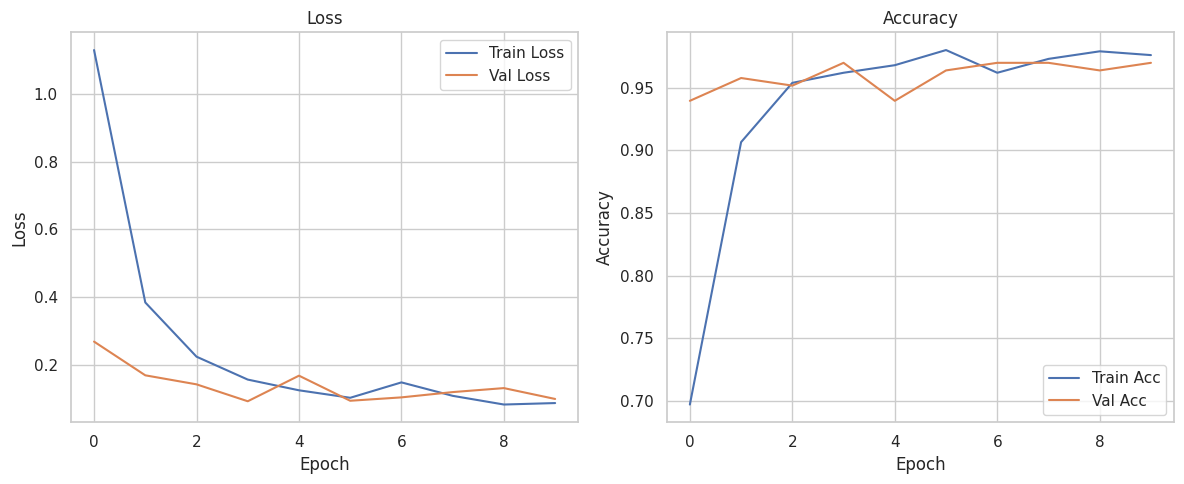

In [15]:
# plot results
plot_training_results(results)

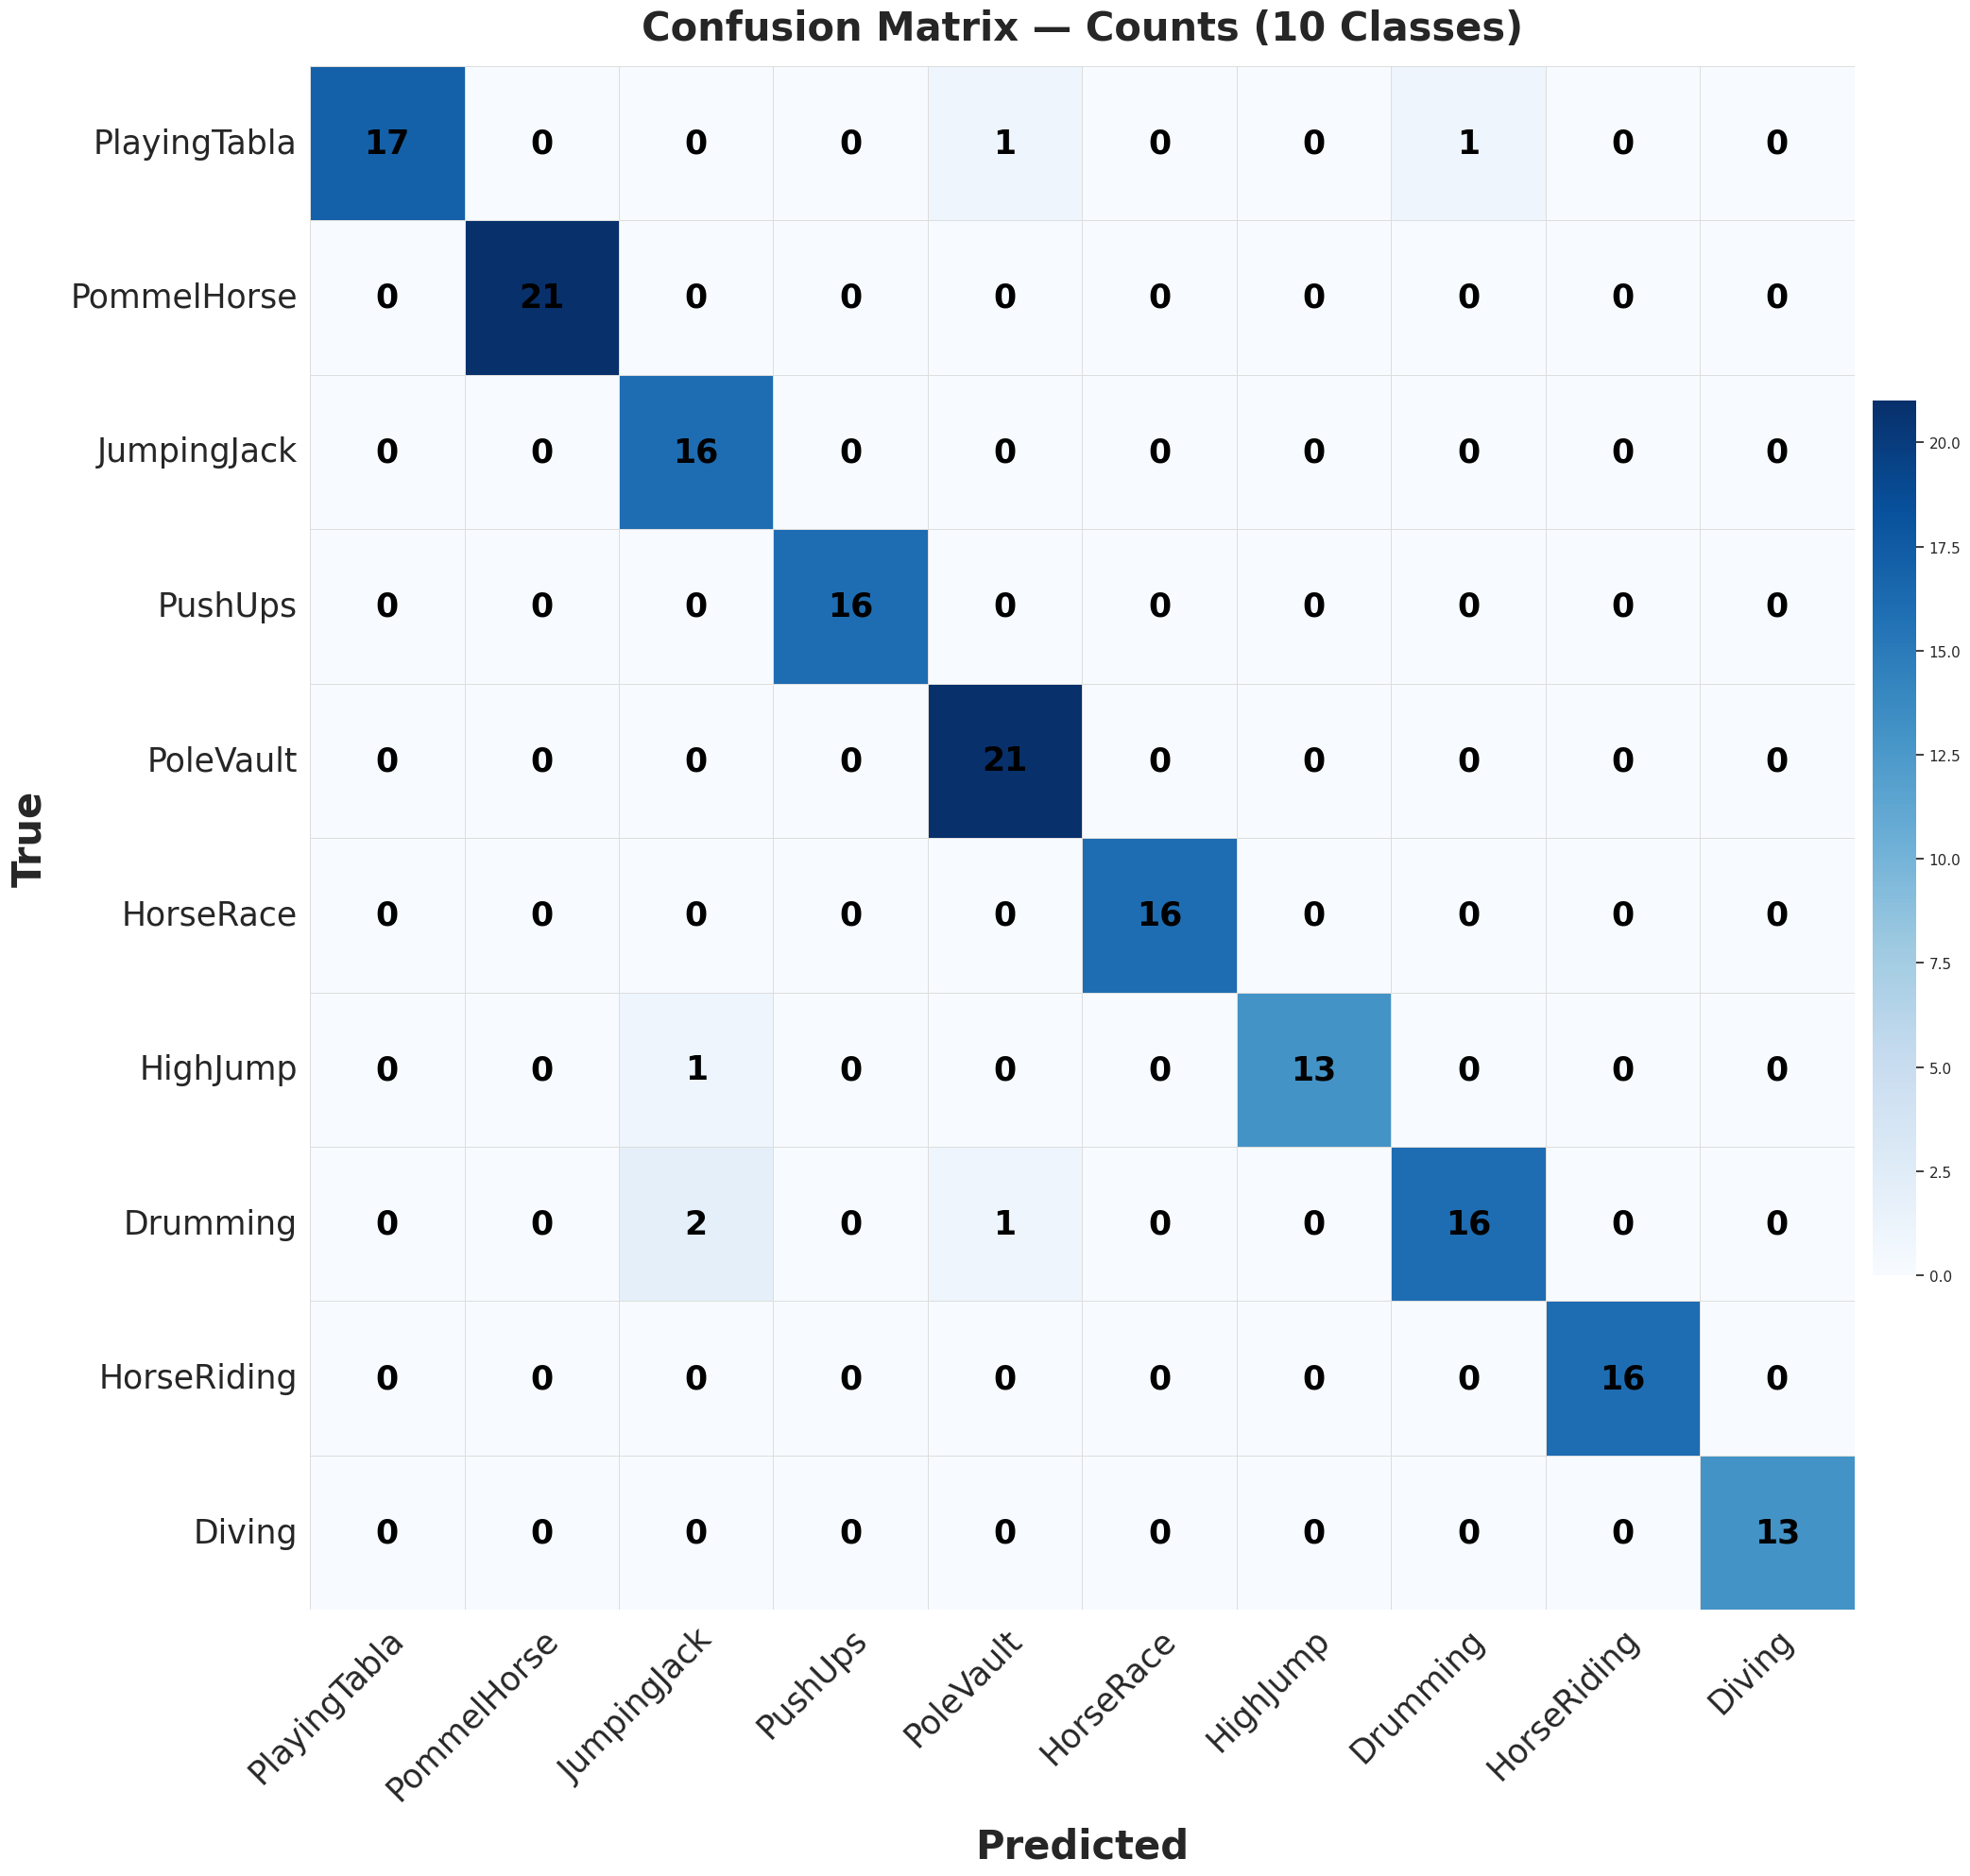

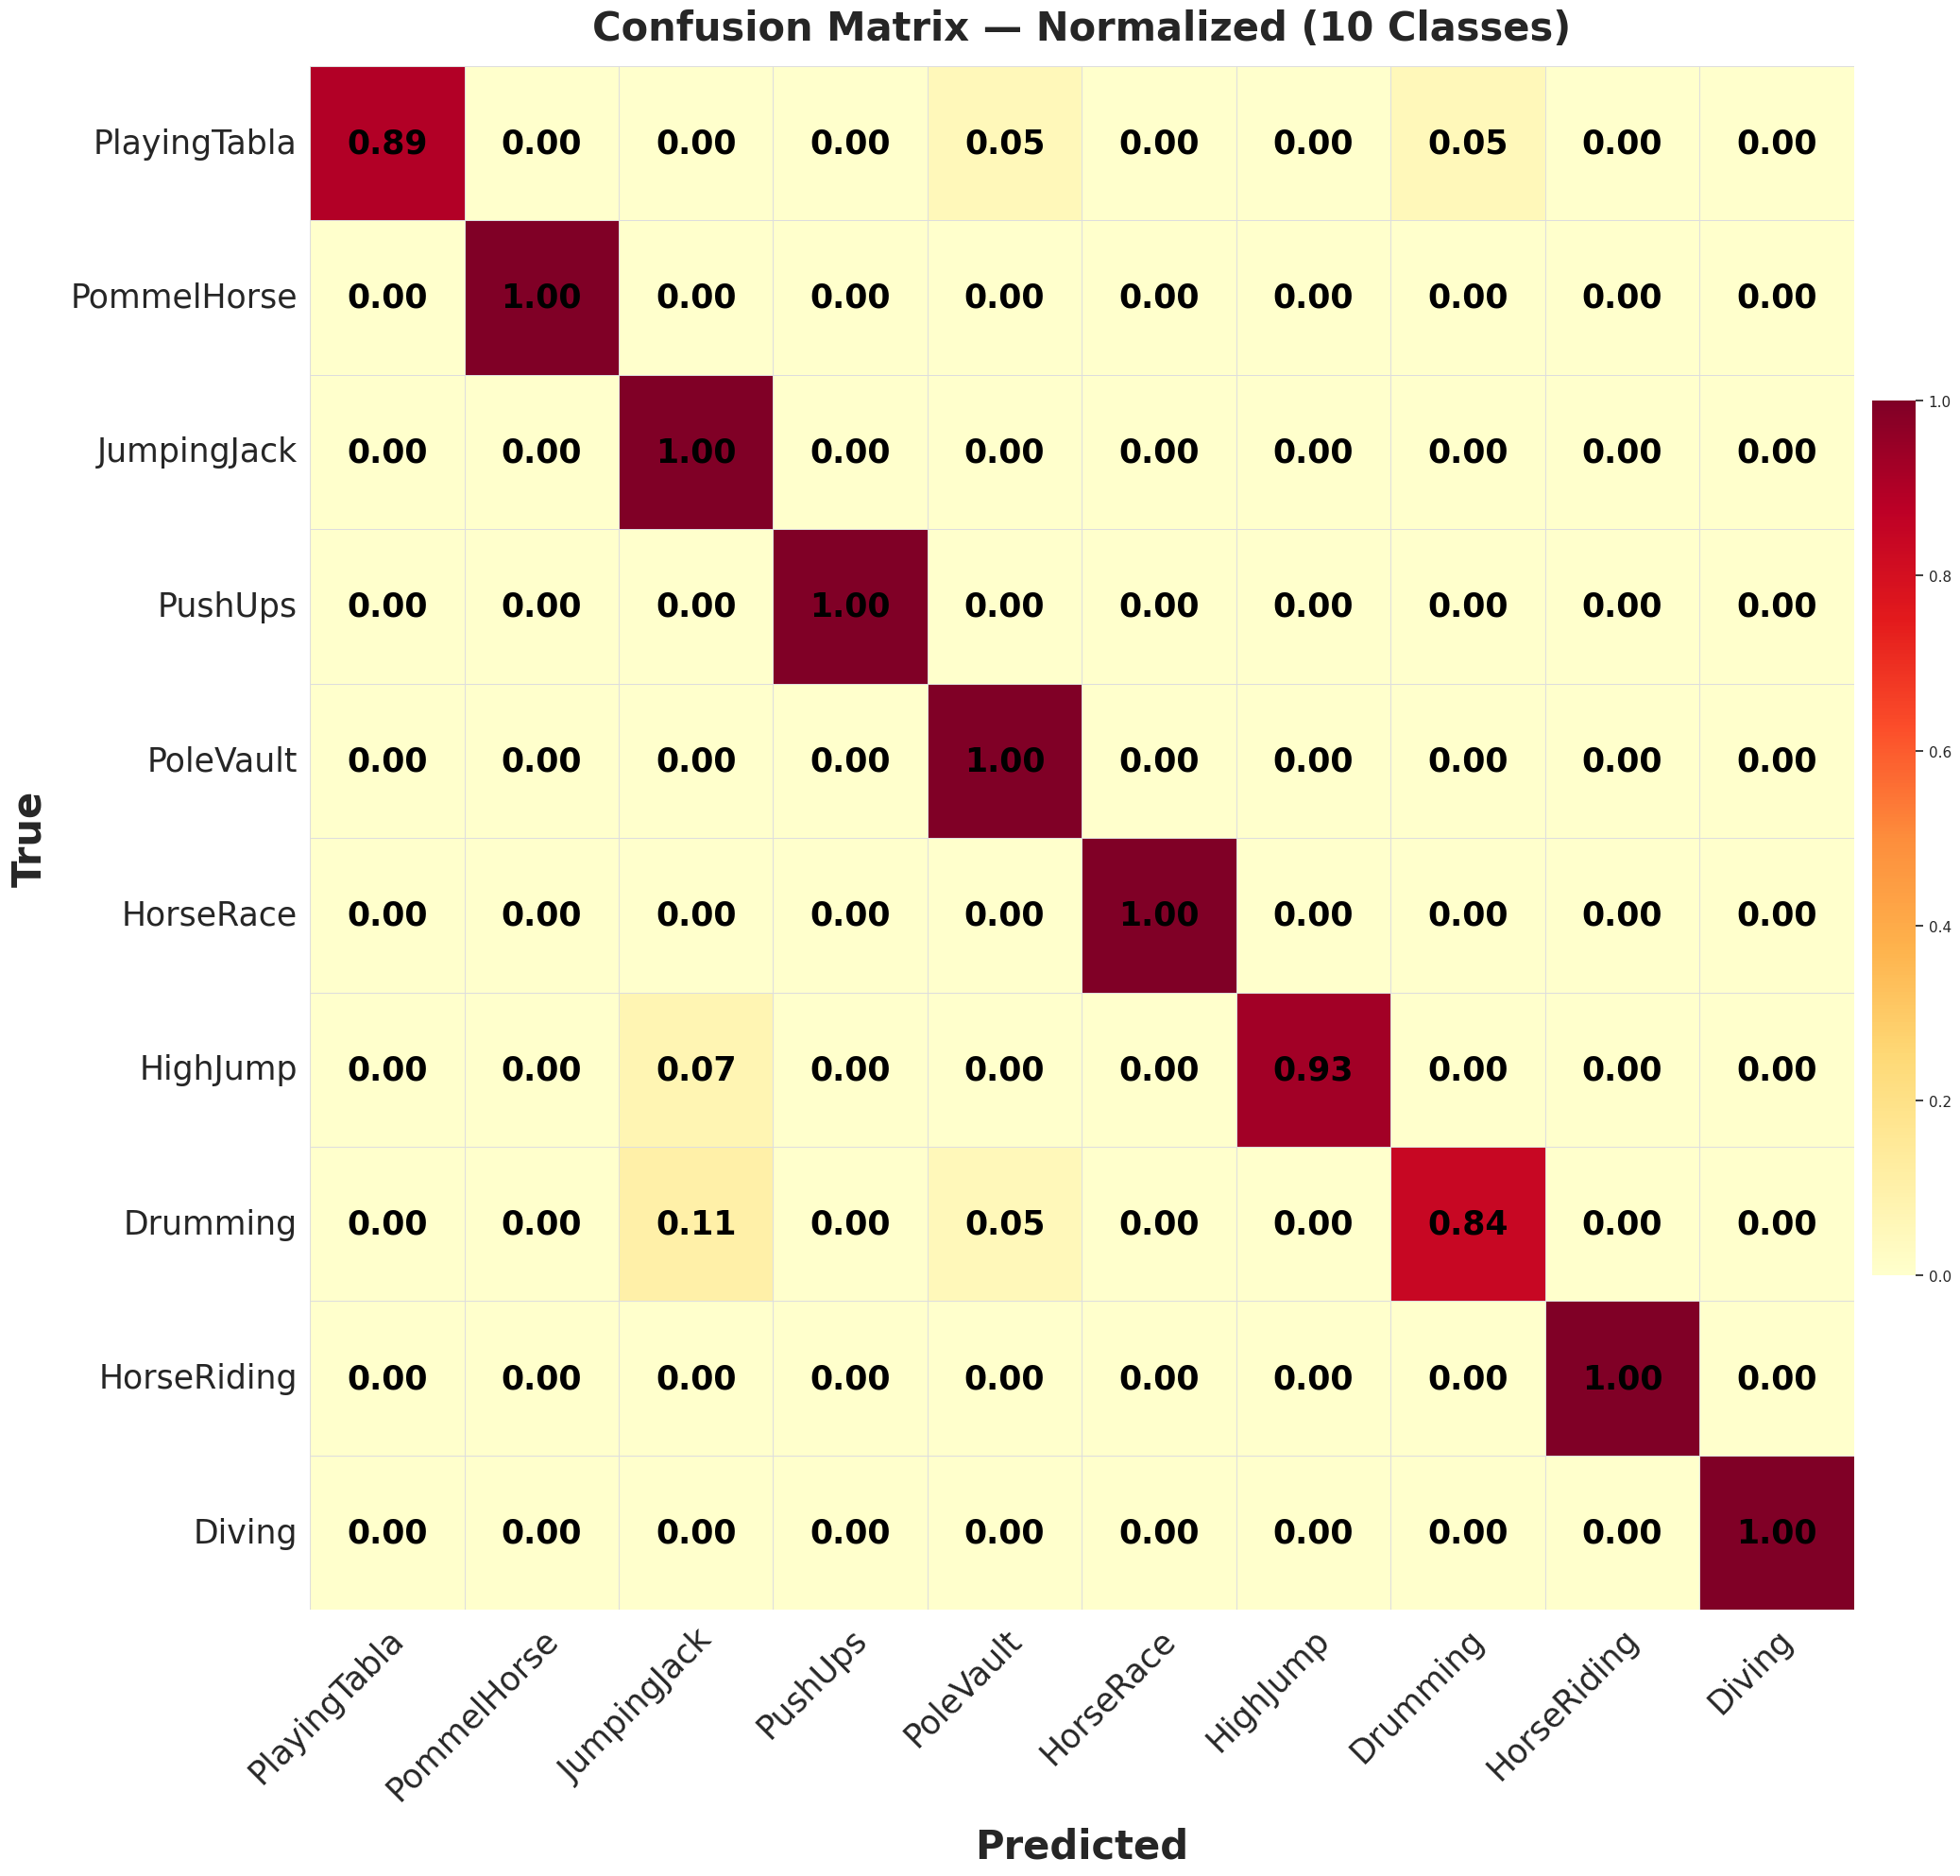

In [16]:
# plot cm
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [17]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS (Weighted Average)
  Accuracy  : 0.9649
  Precision : 0.9680
  Recall    : 0.9649
  F1-Score  : 0.9648

PER-CLASS METRICS
              precision    recall  f1-score   support

PlayingTabla       1.00      0.89      0.94        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       0.84      1.00      0.91        16
     PushUps       1.00      1.00      1.00        16
   PoleVault       0.91      1.00      0.95        21
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      0.93      0.96        14
    Drumming       0.94      0.84      0.89        19
 HorseRiding       1.00      1.00      1.00        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.96       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.96      0.96       171


TOP 5 BEST CLASSES (F1-Score):
  Diving                   : 1.0000
  HorseRiding              : 1.0000
  Hors

## **RESNET50 + LSTM**

In [18]:
model_ResNet50 = ResNet50LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


In [19]:
summary(model_ResNet50, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet50LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 2048, 1, 1]          --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 256, 56, 56]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 56, 56]         (75,008)
│    │    └─Bottleneck: 3-2                   [16, 256, 56, 56]         (70,400)
│    │    └─Bottleneck: 3-3                   [16, 256, 56, 56]         (70,400)
│    └─Sequential: 2-6                        [16, 512, 28, 28]         --
│    │    └─Bottleneck: 3-4                   [16, 512, 28, 28]      

In [20]:
optimizer = optim.Adam(model_ResNet50.parameters(), lr=1e-4)

#### **New folders on drive**

In [21]:
# path
base_path = '/content/drive/MyDrive/apai/resnet50'

# folders
folders = ['models', 'features']

# create folders
for folder in folders:
    path = os.path.join(base_path, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/apai/resnet50/models
Created: /content/drive/MyDrive/apai/resnet50/features


In [22]:
# fine tune
results = fine_tune_model(model_ResNet50, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=True, save_path='/content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth')

Epoch [1/10] Train Loss: 1.1579 Acc: 0.6469 | Val Loss: 0.2695 Acc: 0.9394
  -> Best val loss: 0.2695
Epoch [2/10] Train Loss: 0.2990 Acc: 0.9195 | Val Loss: 0.1485 Acc: 0.9758
  -> Best val loss: 0.1485
Epoch [3/10] Train Loss: 0.1573 Acc: 0.9557 | Val Loss: 0.0905 Acc: 0.9758
  -> Best val loss: 0.0905
Epoch [4/10] Train Loss: 0.1030 Acc: 0.9728 | Val Loss: 0.1017 Acc: 0.9697
Epoch [5/10] Train Loss: 0.0564 Acc: 0.9889 | Val Loss: 0.0961 Acc: 0.9758
Epoch [6/10] Train Loss: 0.0479 Acc: 0.9889 | Val Loss: 0.1210 Acc: 0.9697
Epoch [7/10] Train Loss: 0.0456 Acc: 0.9899 | Val Loss: 0.1352 Acc: 0.9697
Epoch [8/10] Train Loss: 0.0243 Acc: 0.9940 | Val Loss: 0.1119 Acc: 0.9758
Epoch [9/10] Train Loss: 0.0315 Acc: 0.9940 | Val Loss: 0.1011 Acc: 0.9818
Epoch [10/10] Train Loss: 0.0273 Acc: 0.9950 | Val Loss: 0.0868 Acc: 0.9758
  -> Best val loss: 0.0868
Best model saved: /content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth


### **UPLOAD BEST SAVED**

In [24]:
model_path = '/content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth'

# model for feature extraction
model_ResNet50 = ResNet50LSTM(hidden_size=256, num_classes=10).to(device)
checkpoint = torch.load(model_path, map_location=device)
model_ResNet50.load_state_dict(checkpoint)

<All keys matched successfully>

In [25]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model_ResNet50, test_loader, device=device)

Test Accuracy: 0.9825


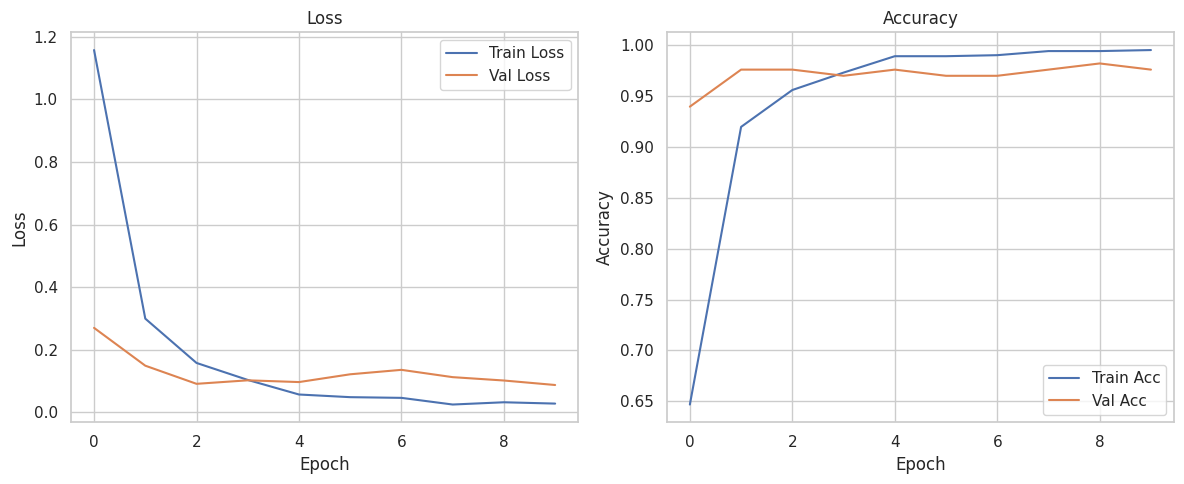

In [26]:
# plot results
plot_training_results(results)

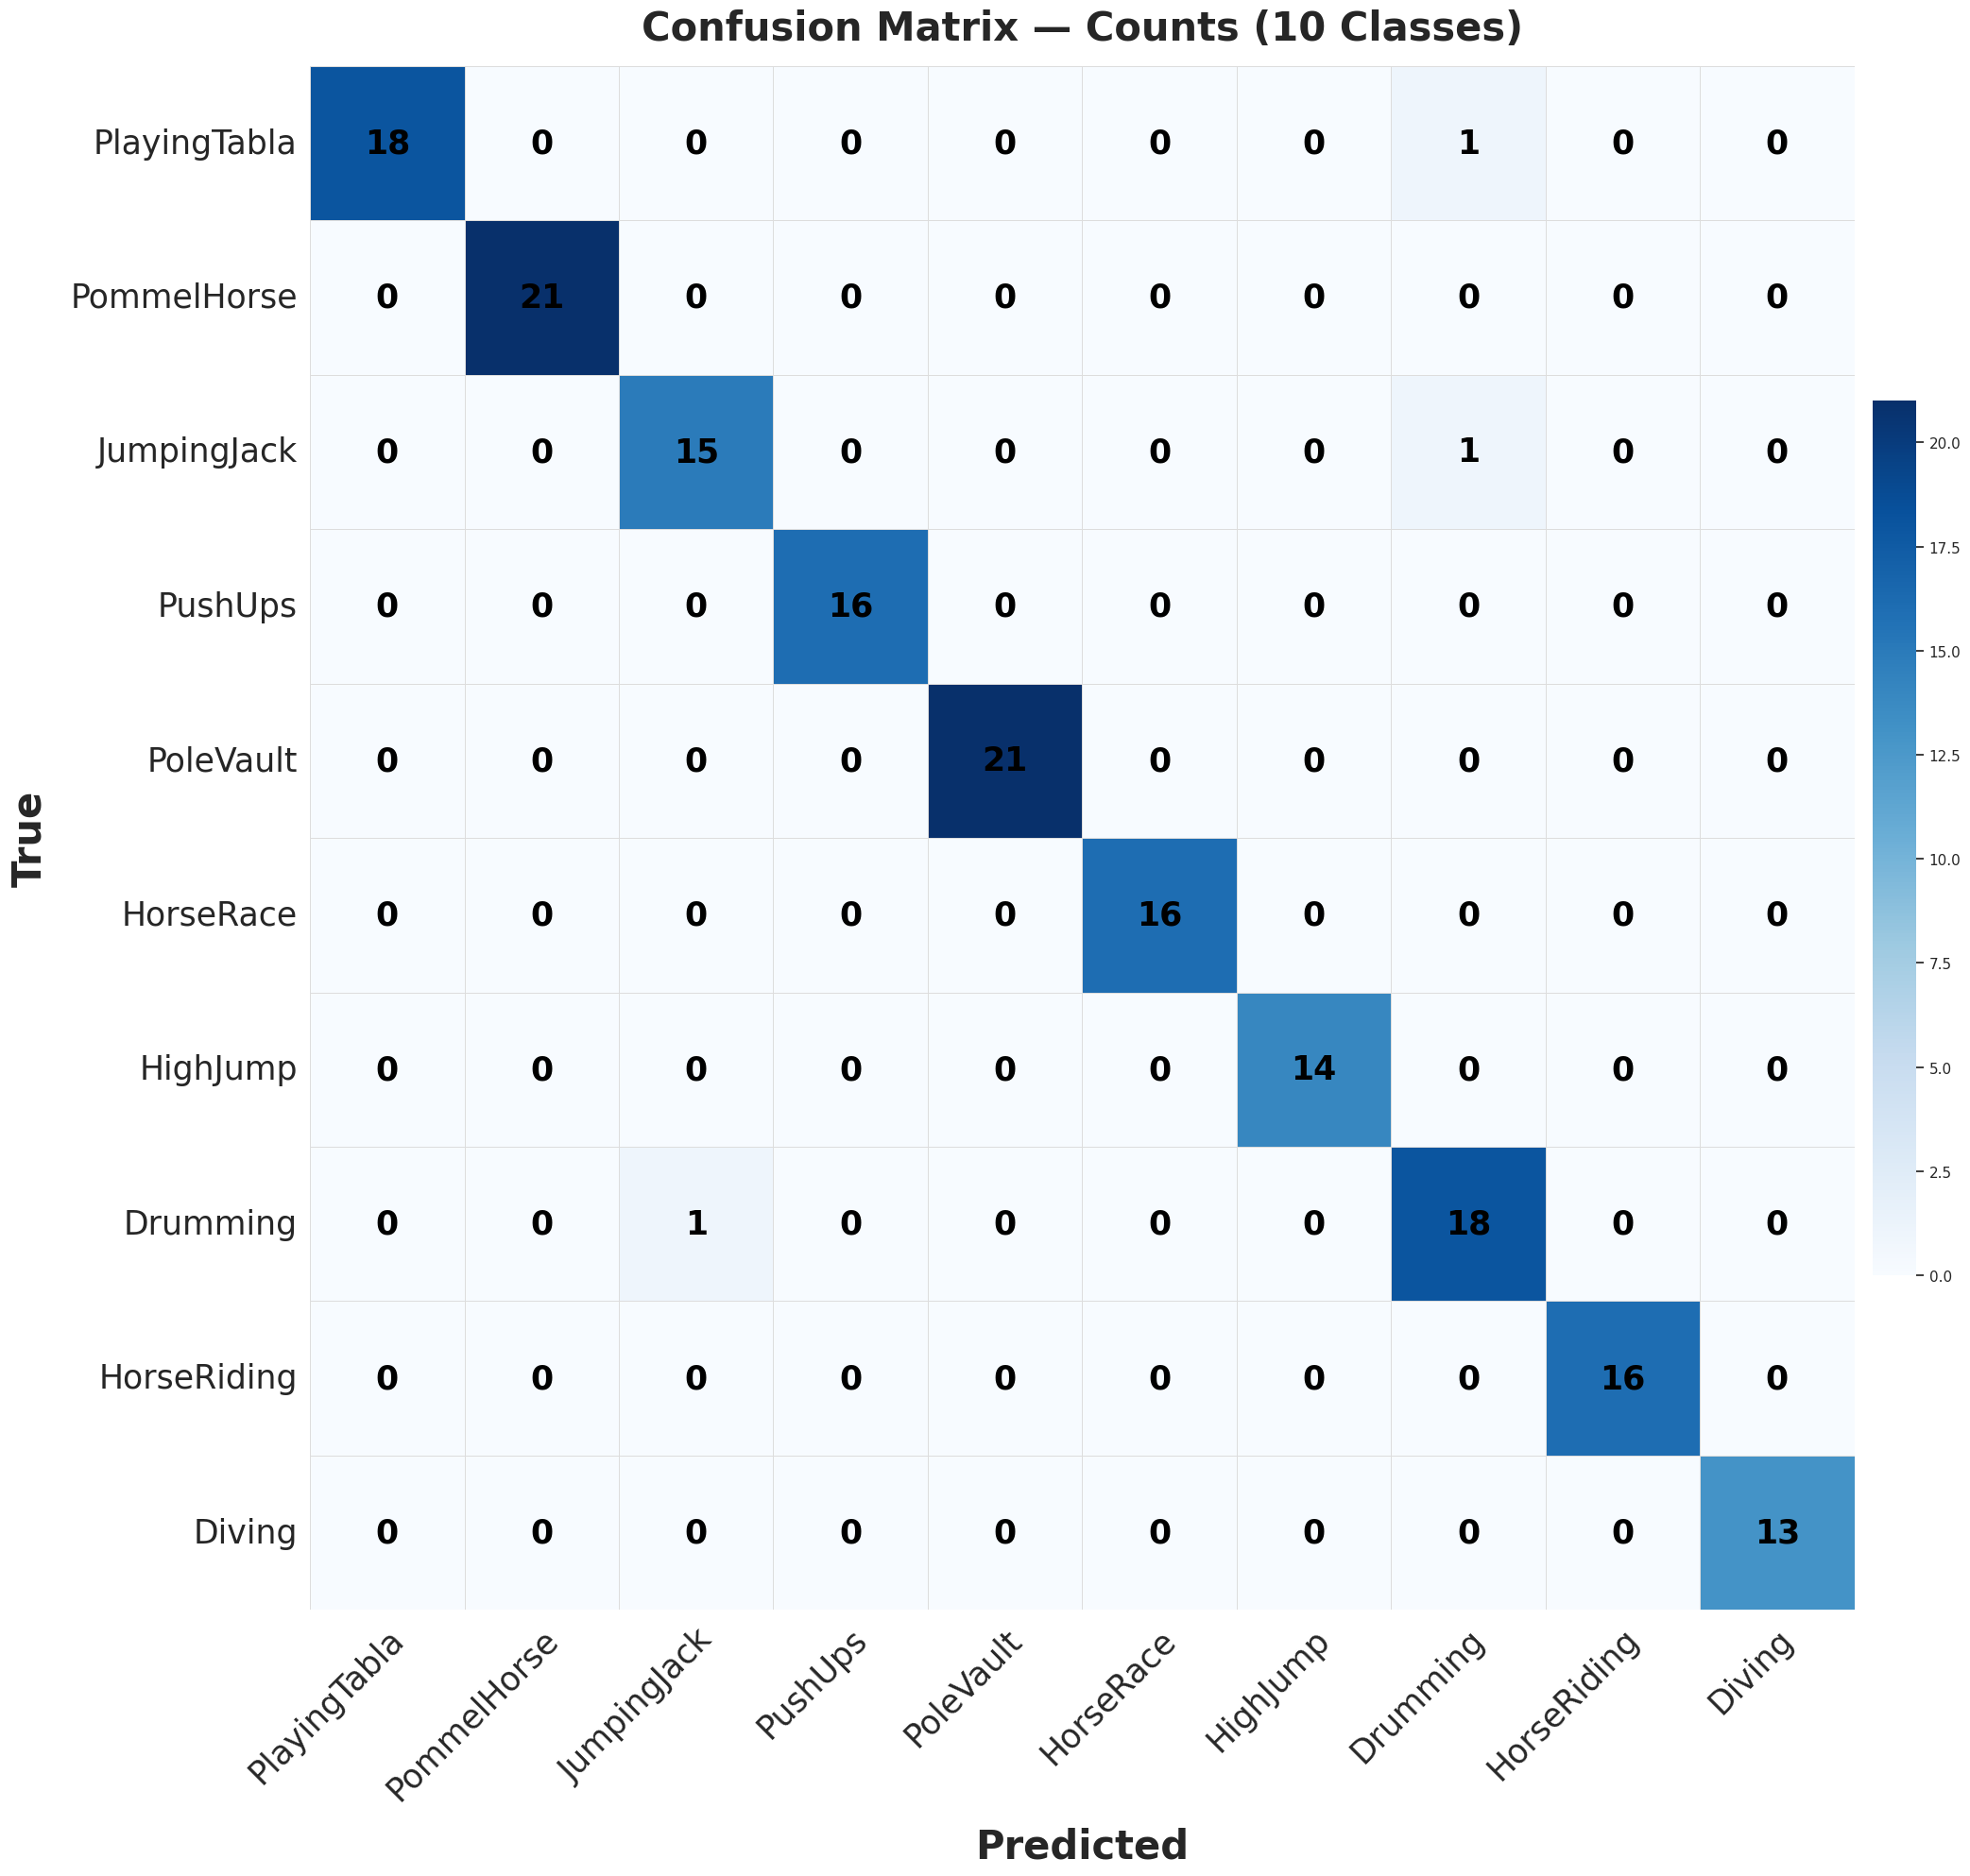

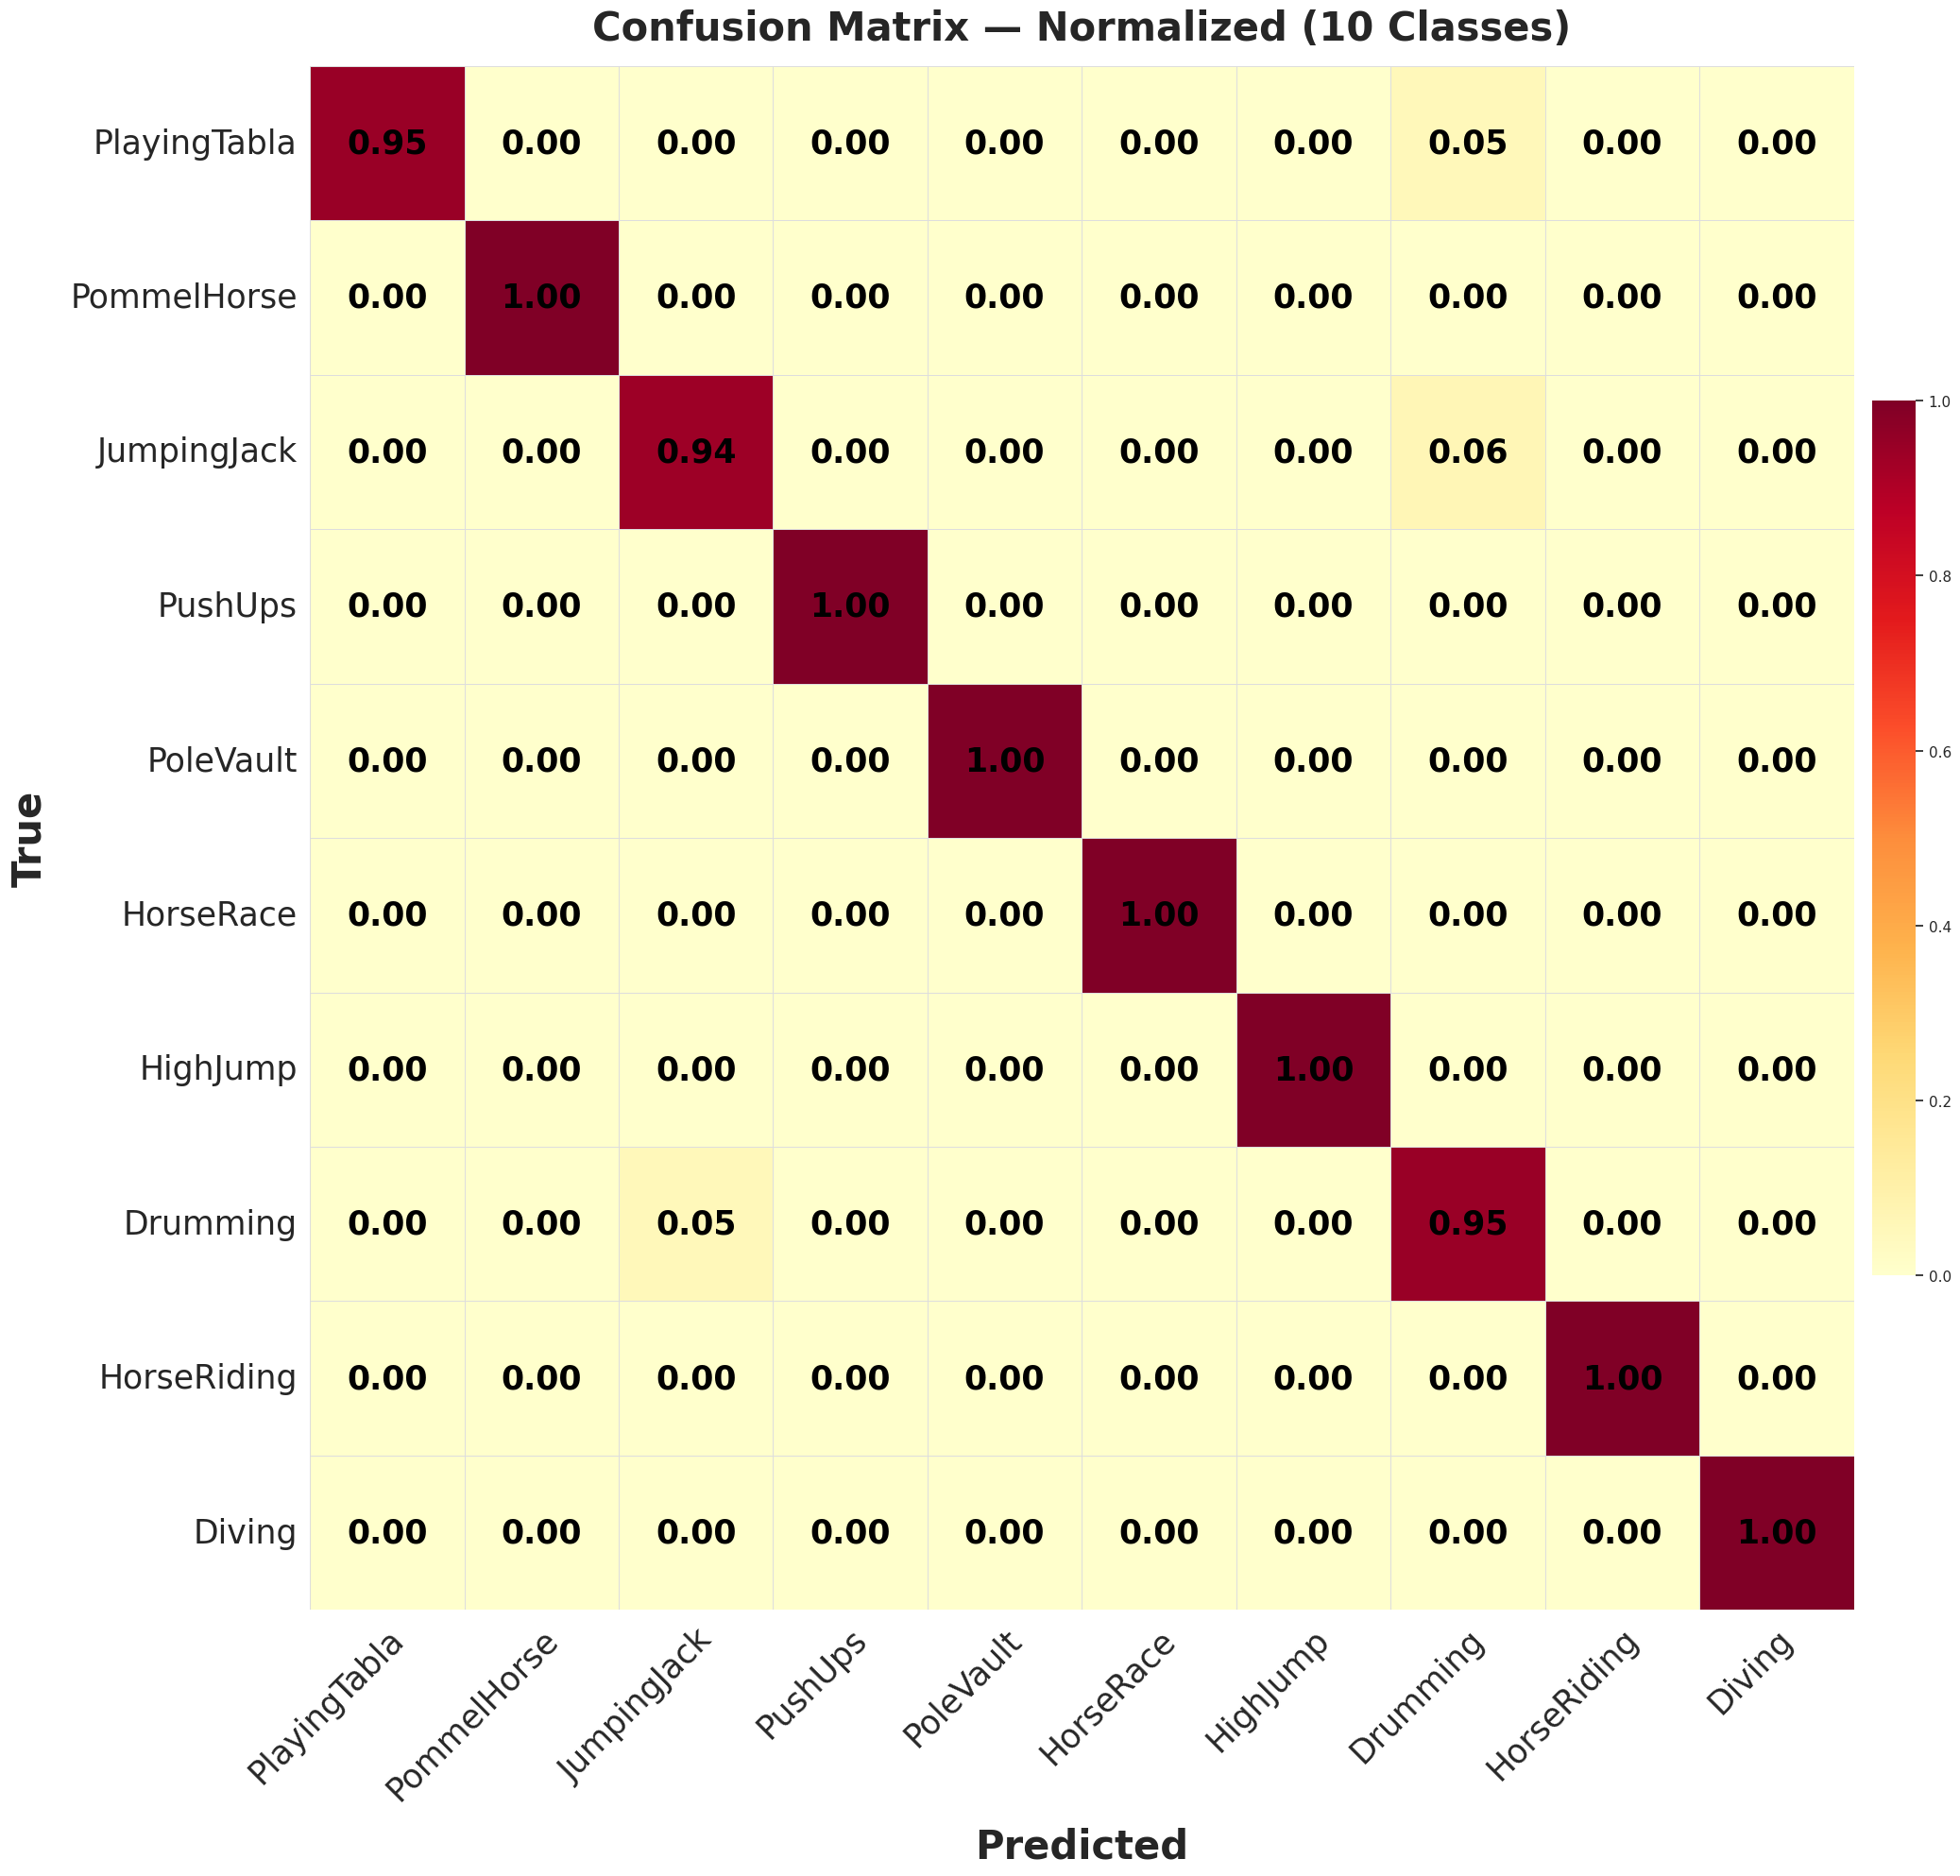

In [29]:
# plot cm
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [30]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS (Weighted Average)
  Accuracy  : 0.9825
  Precision : 0.9830
  Recall    : 0.9825
  F1-Score  : 0.9826

PER-CLASS METRICS
              precision    recall  f1-score   support

PlayingTabla       1.00      0.95      0.97        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       0.94      0.94      0.94        16
     PushUps       1.00      1.00      1.00        16
   PoleVault       1.00      1.00      1.00        21
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      1.00      1.00        14
    Drumming       0.90      0.95      0.92        19
 HorseRiding       1.00      1.00      1.00        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


TOP 5 BEST CLASSES (F1-Score):
  Diving                   : 1.0000
  HorseRiding              : 1.0000
  High

## **DenseNet121 + LSTM**

In [32]:
model = DenseNet121LSTM().to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 156MB/s]


In [33]:
summary(model, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet121LSTM                          [1, 10]                   --
├─Sequential: 1-1                        [16, 1024, 7, 7]          --
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [16, 64, 56, 56]          --
│    └─_DenseBlock: 2-5                  [16, 256, 56, 56]         --
│    │    └─_DenseLayer: 3-1             [16, 32, 56, 56]          (45,440)
│    │    └─_DenseLayer: 3-2             [16, 32, 56, 56]          (49,600)
│    │    └─_DenseLayer: 3-3             [16, 32, 56, 56]          (53,760)
│    │    └─_DenseLayer: 3-4             [16, 32, 56, 56]          (57,920)
│    │    └─_DenseLayer: 3-5             [16, 32, 56, 56]          (62,080)
│    │    └─_DenseLayer: 3-6             [16, 3

In [34]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [35]:
# fine-tune
results = fine_tune_model(model, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=False)

Epoch [1/10] Train Loss: 1.3397 Acc: 0.6489 | Val Loss: 0.4350 Acc: 0.9030
Epoch [2/10] Train Loss: 0.3785 Acc: 0.9135 | Val Loss: 0.1628 Acc: 0.9636
Epoch [3/10] Train Loss: 0.2413 Acc: 0.9386 | Val Loss: 0.1145 Acc: 0.9758
Epoch [4/10] Train Loss: 0.1625 Acc: 0.9658 | Val Loss: 0.0981 Acc: 0.9697
Epoch [5/10] Train Loss: 0.1404 Acc: 0.9688 | Val Loss: 0.1095 Acc: 0.9636
Epoch [6/10] Train Loss: 0.1381 Acc: 0.9668 | Val Loss: 0.0867 Acc: 0.9697
Epoch [7/10] Train Loss: 0.0830 Acc: 0.9779 | Val Loss: 0.0960 Acc: 0.9636
Epoch [8/10] Train Loss: 0.0950 Acc: 0.9759 | Val Loss: 0.0772 Acc: 0.9758
Epoch [9/10] Train Loss: 0.0657 Acc: 0.9809 | Val Loss: 0.0822 Acc: 0.9697
Epoch [10/10] Train Loss: 0.0788 Acc: 0.9779 | Val Loss: 0.0831 Acc: 0.9818


In [36]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9825


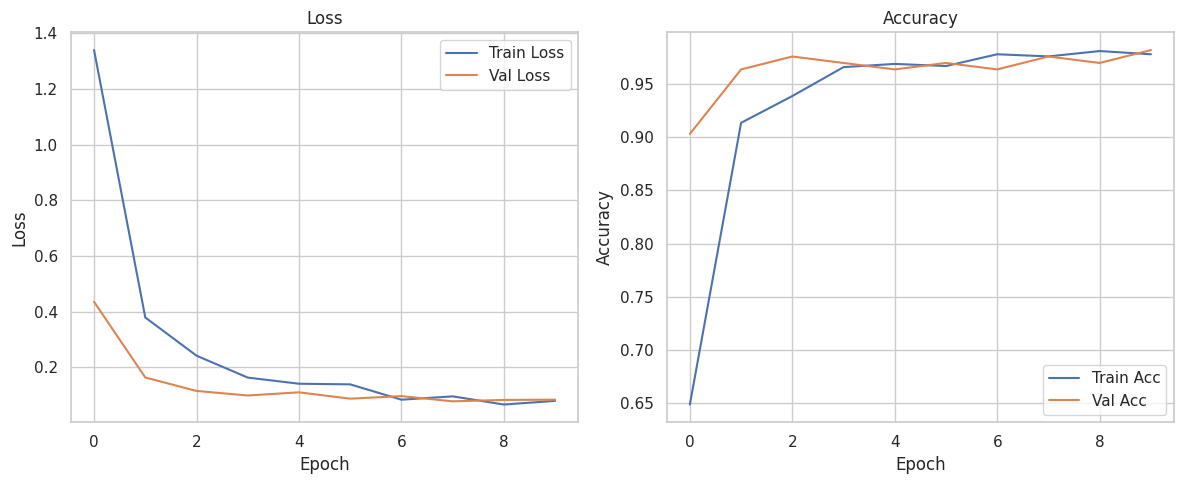

In [37]:
# plot results
plot_training_results(results)

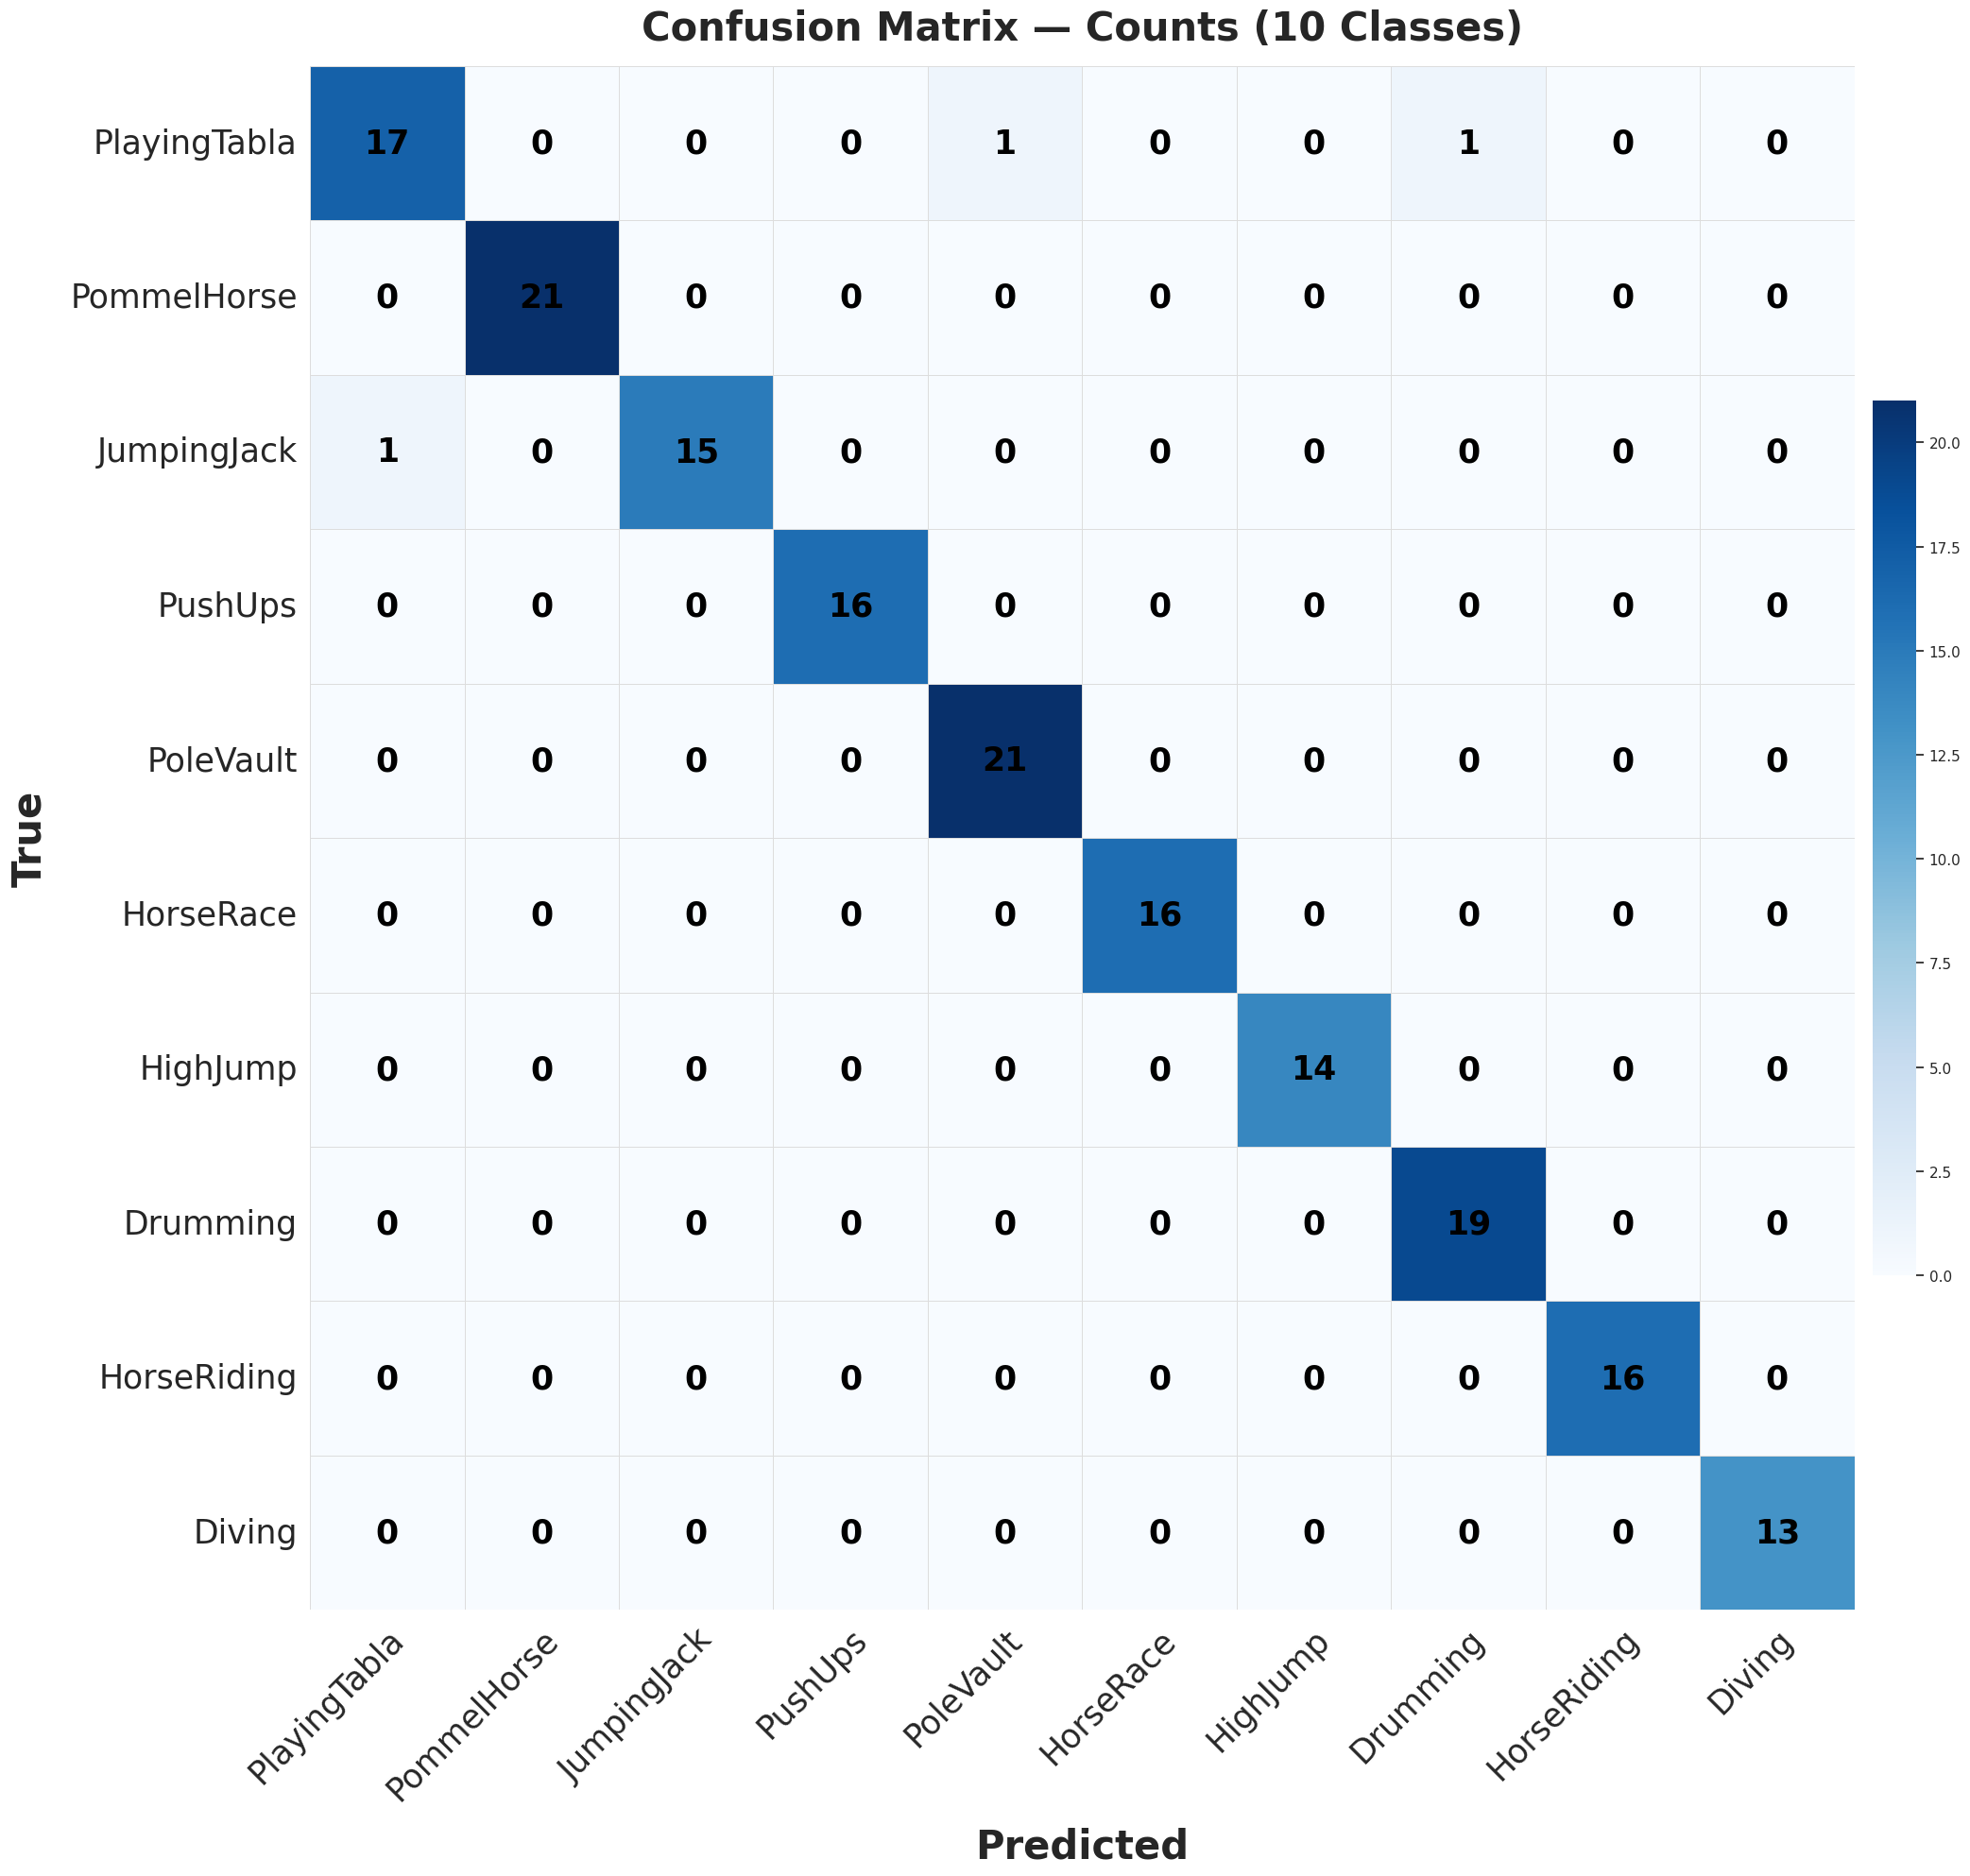

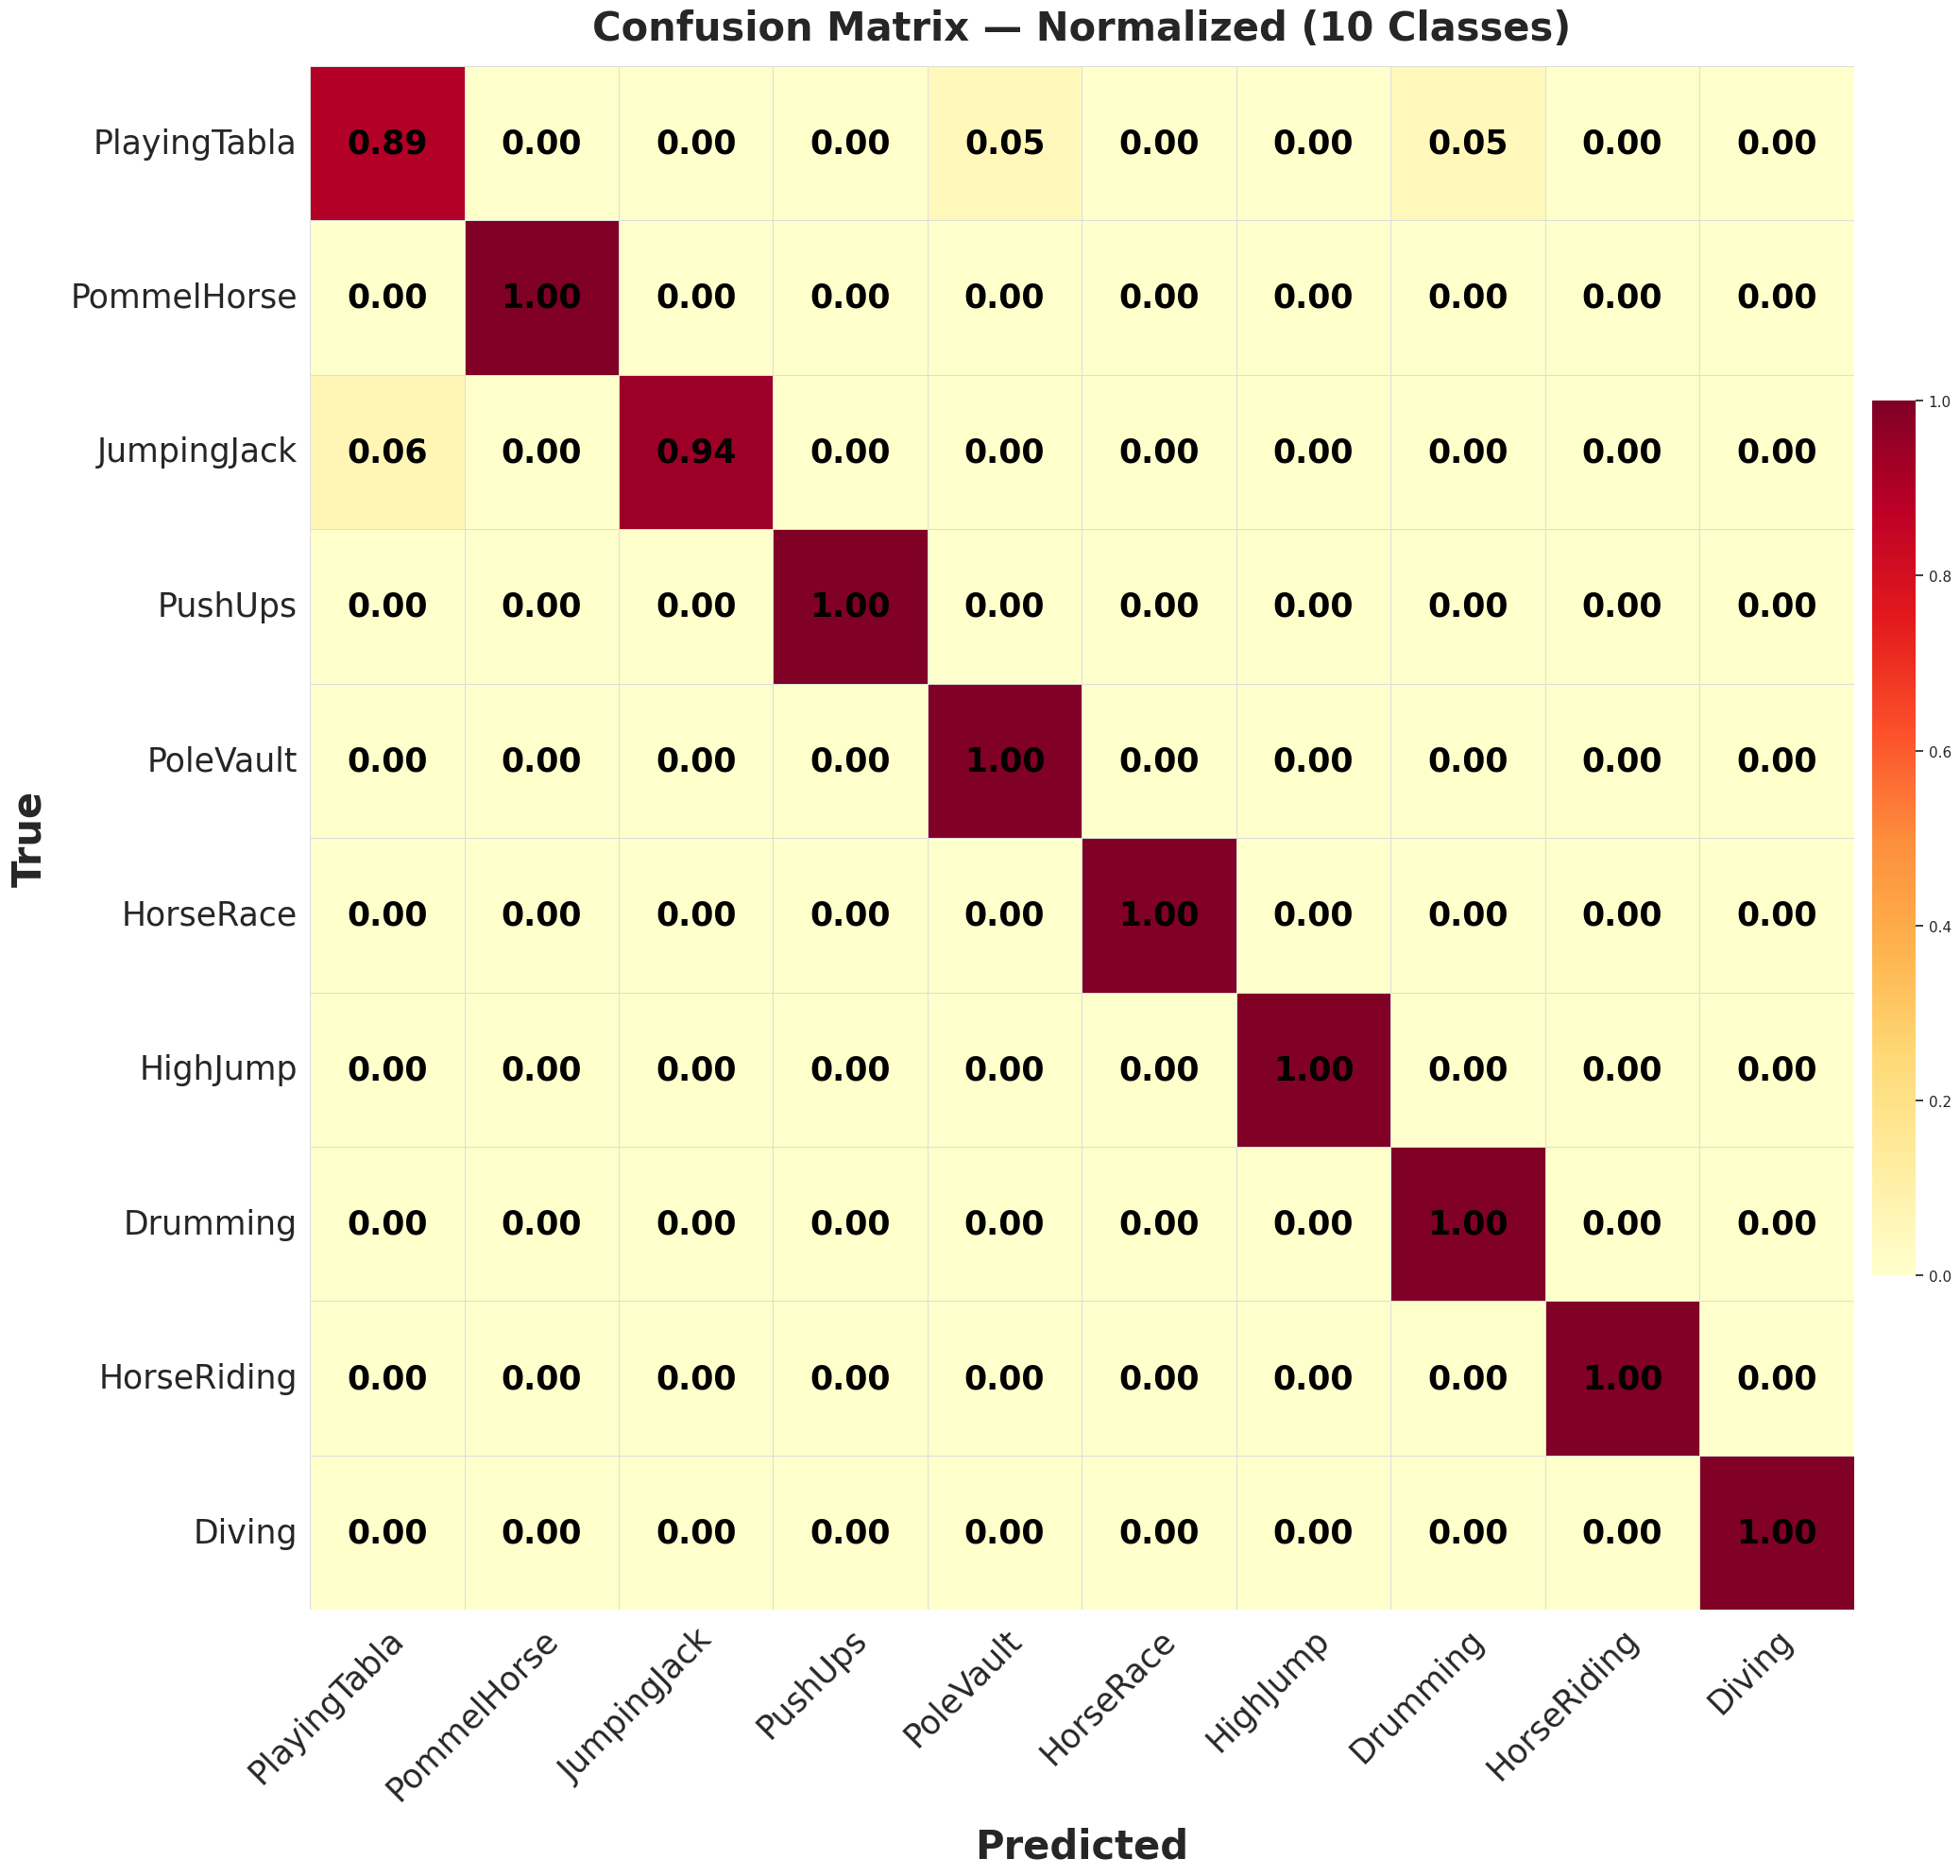

In [38]:
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [39]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS (Weighted Average)
  Accuracy  : 0.9825
  Precision : 0.9827
  Recall    : 0.9825
  F1-Score  : 0.9823

PER-CLASS METRICS
              precision    recall  f1-score   support

PlayingTabla       0.94      0.89      0.92        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       1.00      0.94      0.97        16
     PushUps       1.00      1.00      1.00        16
   PoleVault       0.95      1.00      0.98        21
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      1.00      1.00        14
    Drumming       0.95      1.00      0.97        19
 HorseRiding       1.00      1.00      1.00        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


TOP 5 BEST CLASSES (F1-Score):
  Diving                   : 1.0000
  HorseRiding              : 1.0000
  High

## **VGG19_BN + LSTM**

In [40]:
model = VGG19BNLSTM().to(device)

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:03<00:00, 174MB/s] 


In [41]:
summary(model, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG19BNLSTM                              [1, 10]                   --
├─Sequential: 1-1                        [16, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [16, 64, 224, 224]        (1,792)
│    └─BatchNorm2d: 2-2                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-3                         [16, 64, 224, 224]        --
│    └─Conv2d: 2-4                       [16, 64, 224, 224]        (36,928)
│    └─BatchNorm2d: 2-5                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-6                         [16, 64, 224, 224]        --
│    └─MaxPool2d: 2-7                    [16, 64, 112, 112]        --
│    └─Conv2d: 2-8                       [16, 128, 112, 112]       (73,856)
│    └─BatchNorm2d: 2-9                  [16, 128, 112, 112]       (256)
│    └─ReLU: 2-10                        [16, 128, 112, 112]       --
│    └─Conv2d: 2-11                      [16, 128, 112, 112

In [42]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [43]:
# fine-tune
results = fine_tune_model(model, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=False)

Epoch [1/10] Train Loss: 1.2485 Acc: 0.6569 | Val Loss: 0.3194 Acc: 0.9152
Epoch [2/10] Train Loss: 0.4245 Acc: 0.8863 | Val Loss: 0.1793 Acc: 0.9515
Epoch [3/10] Train Loss: 0.2655 Acc: 0.9245 | Val Loss: 0.1383 Acc: 0.9636
Epoch [4/10] Train Loss: 0.2028 Acc: 0.9437 | Val Loss: 0.1303 Acc: 0.9636
Epoch [5/10] Train Loss: 0.1549 Acc: 0.9577 | Val Loss: 0.1248 Acc: 0.9697
Epoch [6/10] Train Loss: 0.1117 Acc: 0.9688 | Val Loss: 0.1343 Acc: 0.9758
Epoch [7/10] Train Loss: 0.0592 Acc: 0.9839 | Val Loss: 0.1831 Acc: 0.9515
Epoch [8/10] Train Loss: 0.0602 Acc: 0.9869 | Val Loss: 0.1194 Acc: 0.9697
Epoch [9/10] Train Loss: 0.0359 Acc: 0.9879 | Val Loss: 0.1985 Acc: 0.9394
Epoch [10/10] Train Loss: 0.0733 Acc: 0.9769 | Val Loss: 0.1391 Acc: 0.9515


In [44]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9825


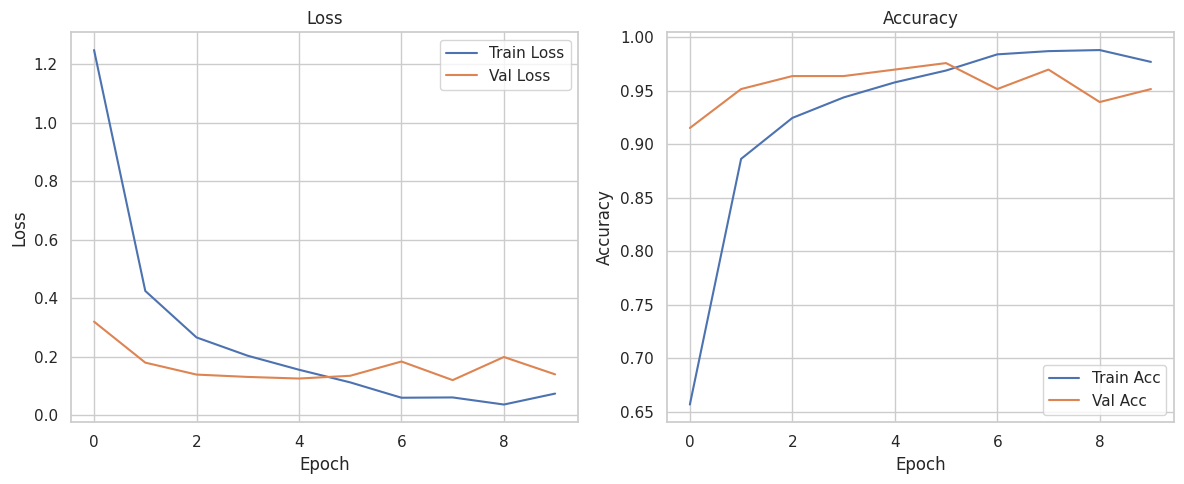

In [45]:
# plot results
plot_training_results(results)

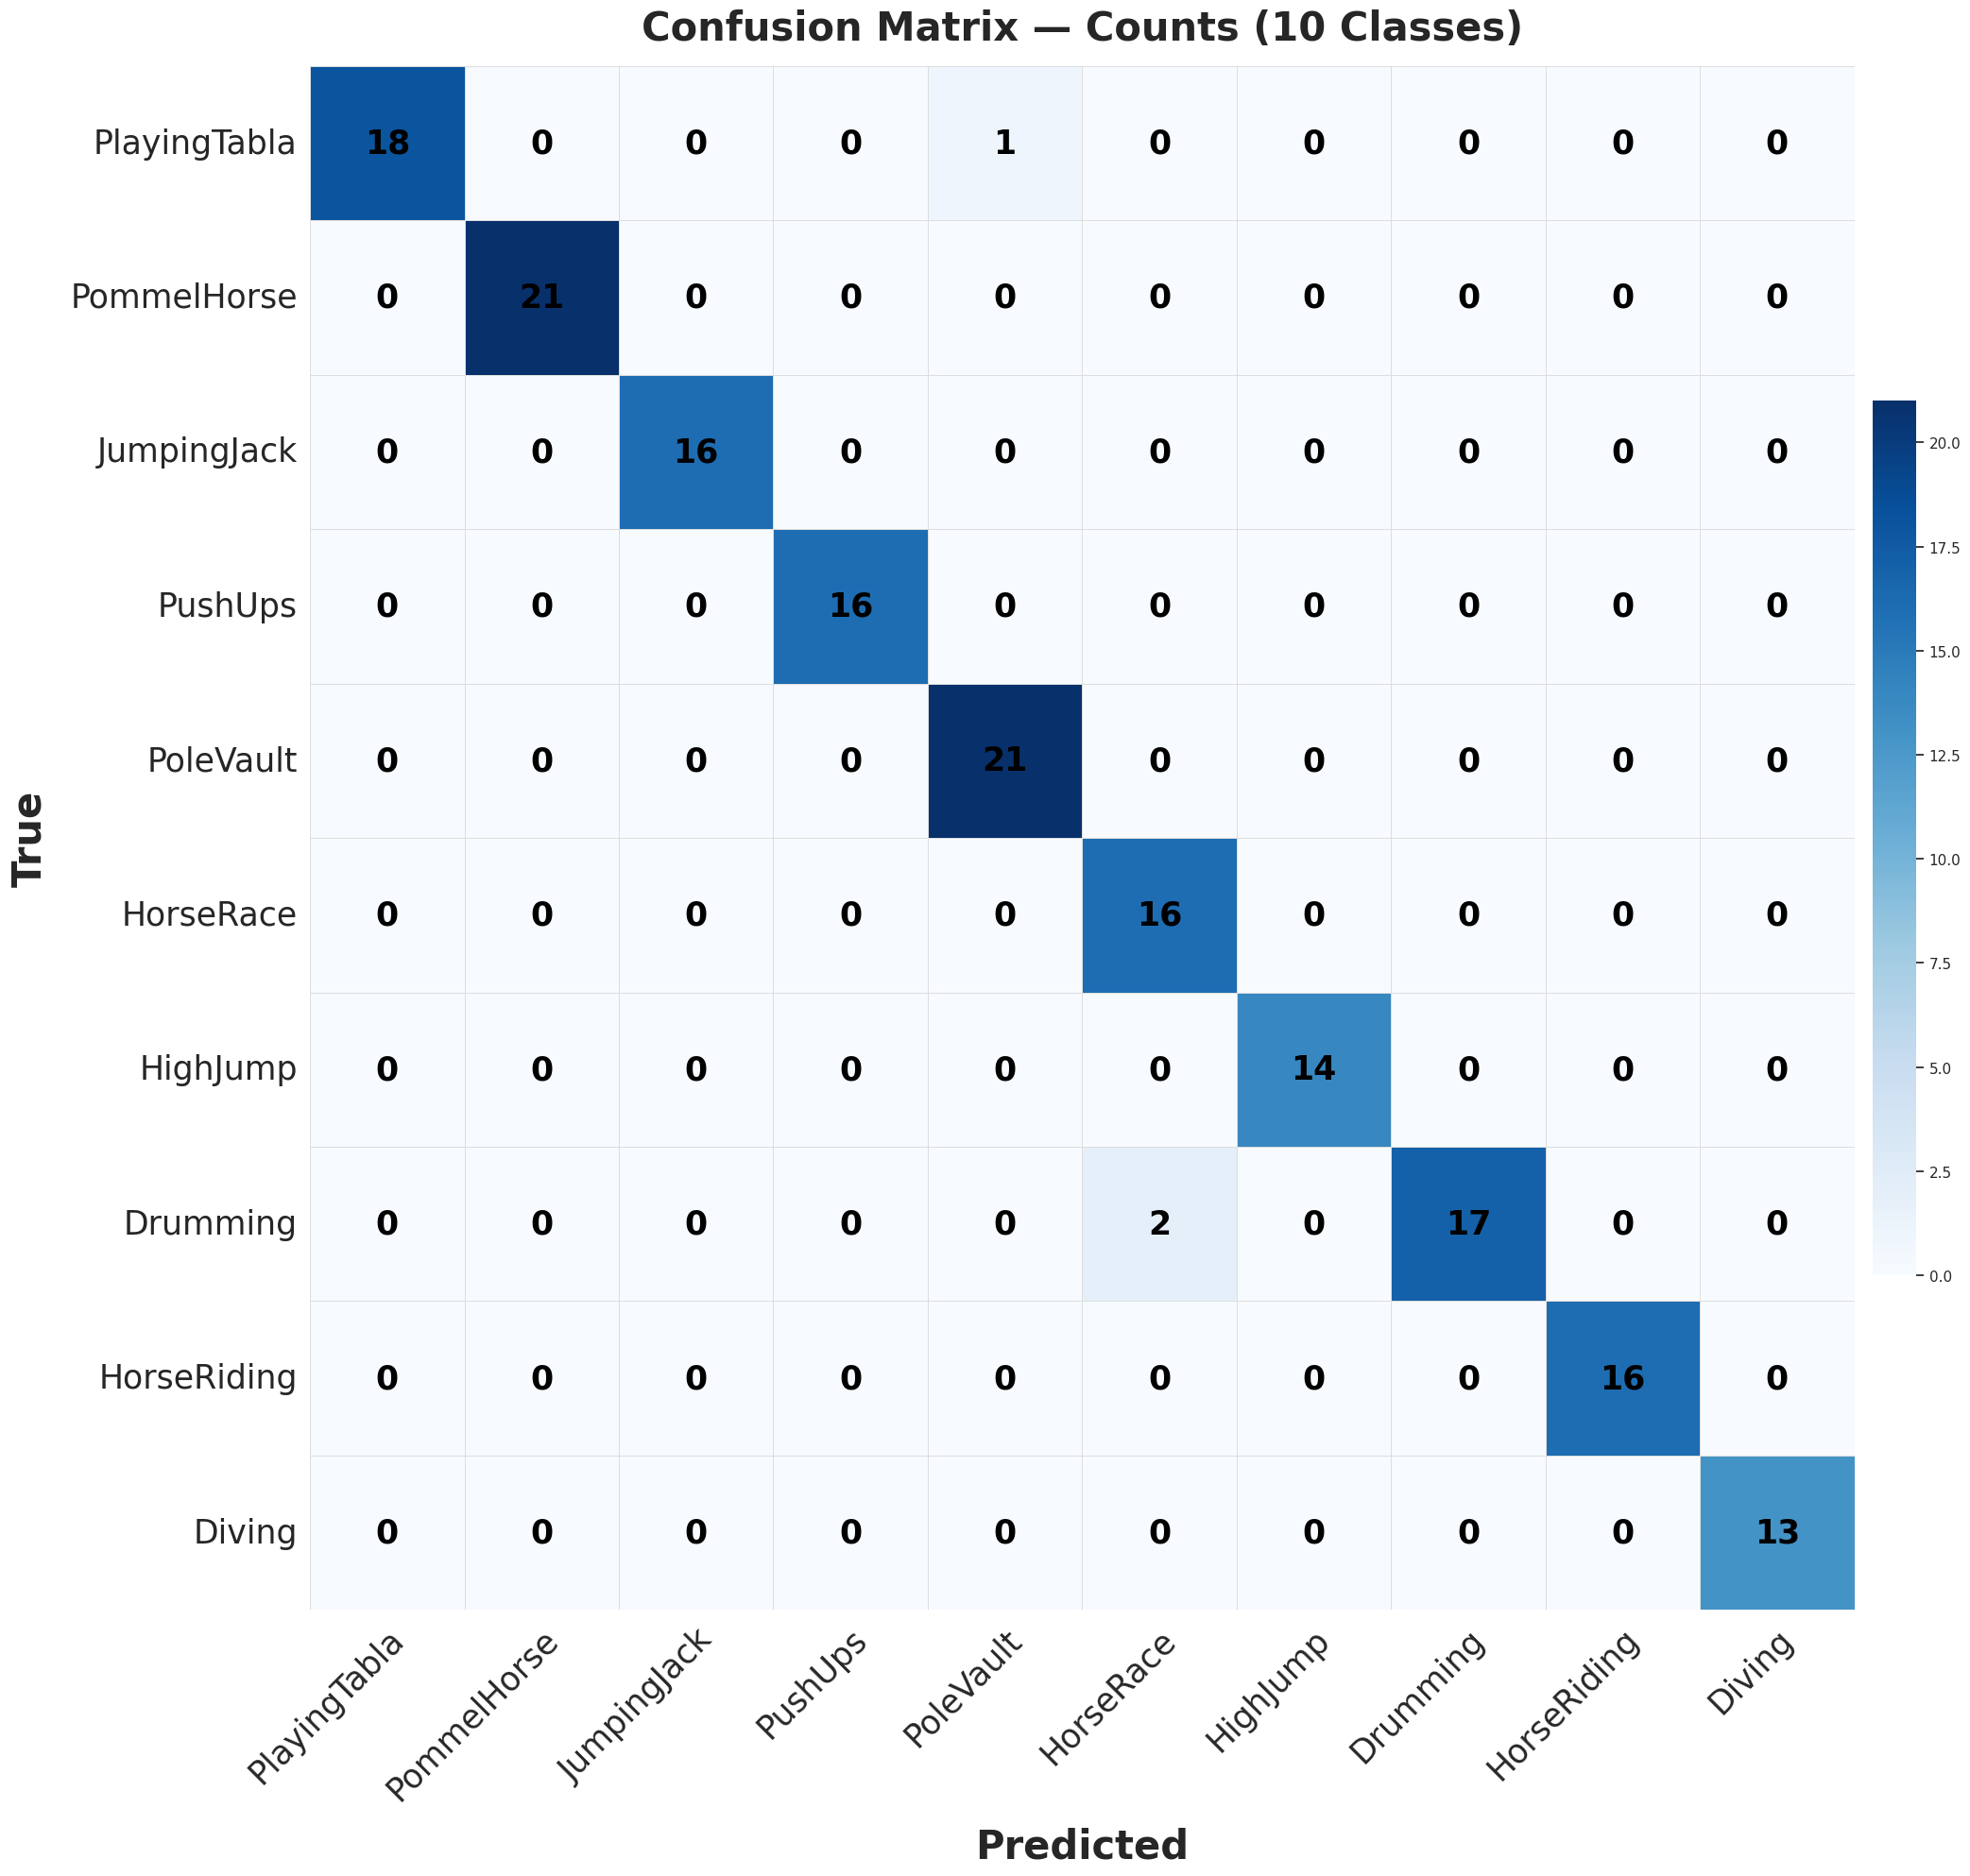

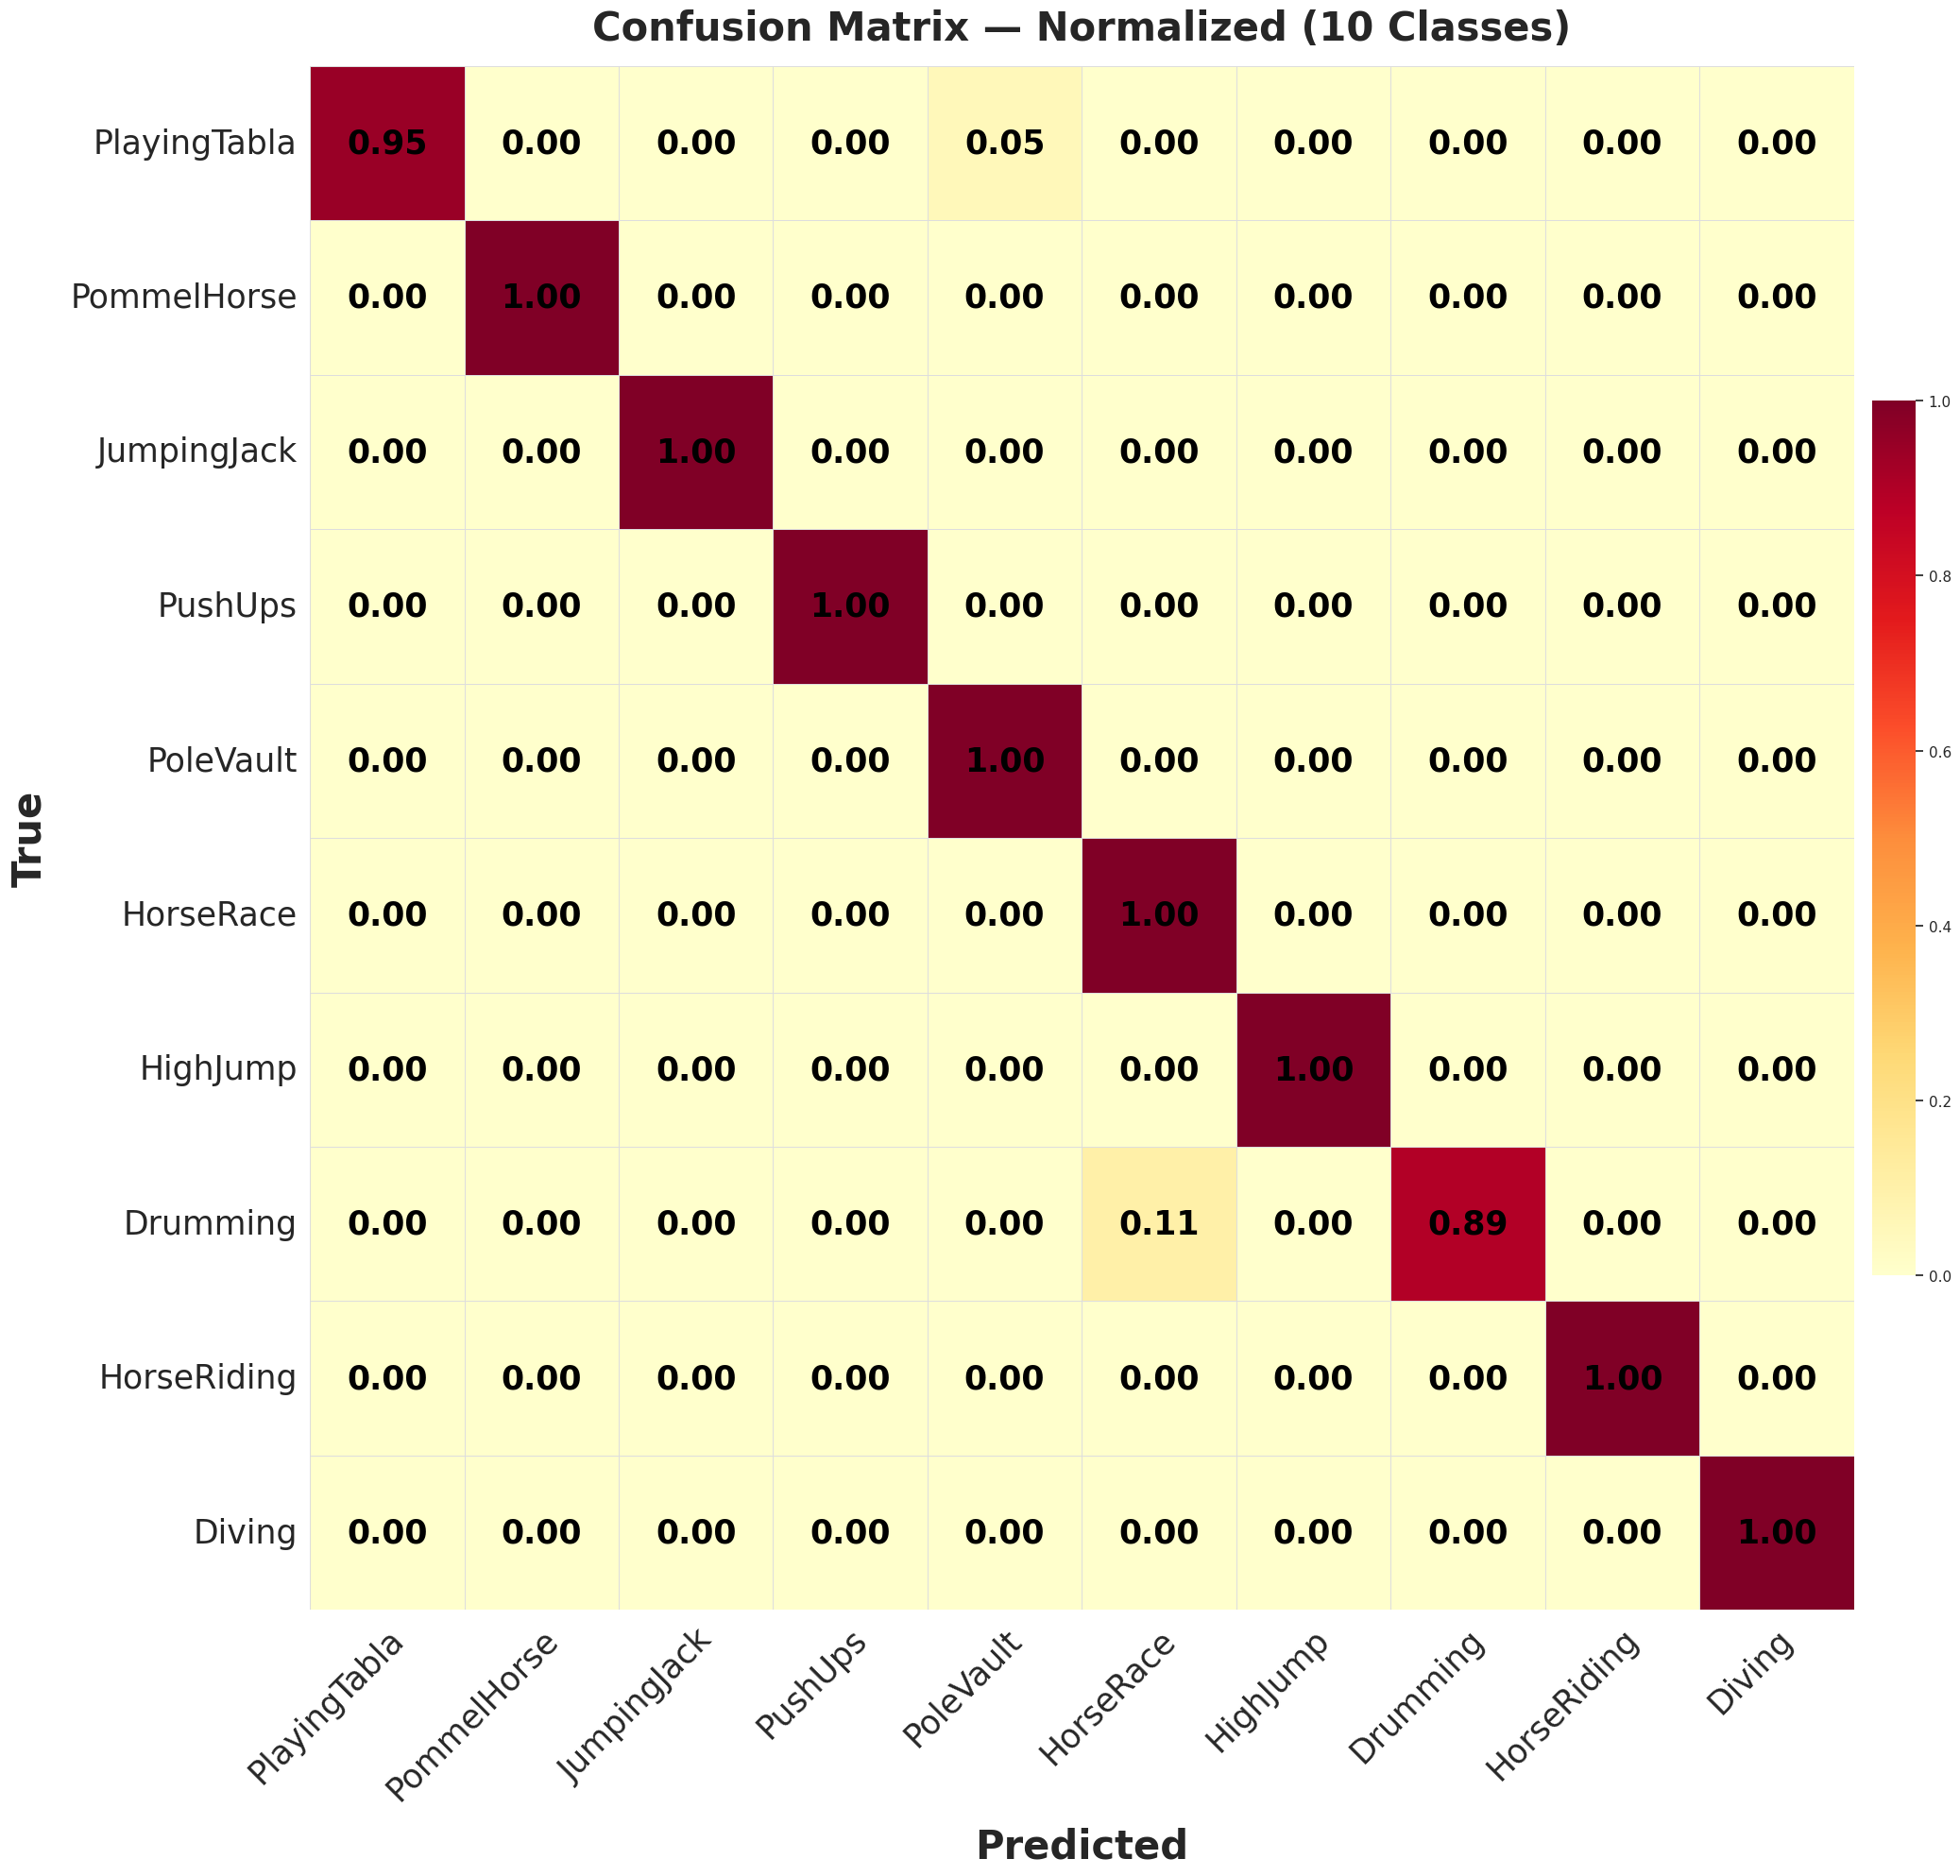

In [46]:
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [47]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS (Weighted Average)
  Accuracy  : 0.9825
  Precision : 0.9840
  Recall    : 0.9825
  F1-Score  : 0.9825

PER-CLASS METRICS
              precision    recall  f1-score   support

PlayingTabla       1.00      0.95      0.97        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       1.00      1.00      1.00        16
     PushUps       1.00      1.00      1.00        16
   PoleVault       0.95      1.00      0.98        21
   HorseRace       0.89      1.00      0.94        16
    HighJump       1.00      1.00      1.00        14
    Drumming       1.00      0.89      0.94        19
 HorseRiding       1.00      1.00      1.00        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


TOP 5 BEST CLASSES (F1-Score):
  Diving                   : 1.0000
  HorseRiding              : 1.0000
  High

## **EXCTRACT FEATRES & SAVE**

In [50]:
# take off classifier weights ('fc')
filtered_checkpoint = {k: v for k, v in checkpoint.items() if not k.startswith('fc.')}

# take only non-classifier layers
model_ResNet50.load_state_dict(filtered_checkpoint, strict=False)

model_ResNet50.eval()
model_ResNet50.to('cuda' if torch.cuda.is_available() else 'cpu')

ResNet50LSTM(
  (resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(

In [51]:
# Paths for saving features
base_path = '/content/drive/MyDrive/apai/resnet50/features'
os.makedirs(base_path, exist_ok=True)

train_features_path = os.path.join(base_path, "train_features.pt")
train_labels_path   = os.path.join(base_path, "train_labels.pt")
val_features_path   = os.path.join(base_path, "val_features.pt")
val_labels_path     = os.path.join(base_path, "val_labels.pt")
test_features_path  = os.path.join(base_path, "test_features.pt")
test_labels_path    = os.path.join(base_path, "test_labels.pt")

print("Features will be saved in:", base_path)

def extract_features(model, clip_tensor):
    batch_size, seq_len, C, H, W = clip_tensor.shape
    clip_tensor = clip_tensor.to(device)
    with torch.no_grad():
        features = model.resnet(clip_tensor.view(batch_size * seq_len, C, H, W))
        features = features.view(batch_size, seq_len, -1)
        lstm_out, _ = model.lstm(features)
        video_features = lstm_out[:, -1, :]  # last timestep
    return video_features.cpu()

def process_dataloader(dataloader, model, features_file, labels_file):
    all_features = []
    all_labels = []
    for clips, labels in dataloader:
        features = extract_features(model, clips)
        all_features.append(features)
        all_labels.append(labels.cpu())
    all_features = torch.cat(all_features, dim=0)
    all_labels   = torch.cat(all_labels, dim=0)
    torch.save(all_features, features_file)
    torch.save(all_labels, labels_file)
    print(f"Saved features to {features_file}")
    print(f"Saved labels to {labels_file}")
    return all_features, all_labels

# exctract features for each train, val, test
train_features, train_labels = process_dataloader(train_loader, model_ResNet50, train_features_path, train_labels_path)
val_features, val_labels     = process_dataloader(val_loader, model_ResNet50, val_features_path, val_labels_path)
test_features, test_labels   = process_dataloader(test_loader, model_ResNet50, test_features_path, test_labels_path)

Features will be saved in: /content/drive/MyDrive/apai/resnet50/features


Saved features to /content/drive/MyDrive/apai/resnet50/features/train_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/train_labels.pt
Saved features to /content/drive/MyDrive/apai/resnet50/features/val_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/val_labels.pt
Saved features to /content/drive/MyDrive/apai/resnet50/features/test_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/test_labels.pt
